In [ ]:
import json, requests, gzip, re, os
import pandas as pd
import numpy as np
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt
from scipy.stats import binomtest

OUT_DIR = Path("../data/gdc_cache")
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR = Path("data/tcga_maf")
DATA_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR = Path("data/tcga_omics")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MAX_WORKERS = 8

CANCERS = [
    "TCGA-BLCA",  # Bladder Urothelial Carcinoma
    "TCGA-BRCA",  # Breast Invasive Carcinoma
    "TCGA-CESC",  # Cervical Squamous Cell Carcinoma
    "TCGA-CHOL",  # Cholangiocarcinoma
    "TCGA-COAD",  # Colon Adenocarcinoma
    "TCGA-DLBC",  # Diffuse Large B-cell Lymphoma
    "TCGA-ESCA",  # Esophageal Carcinoma
    "TCGA-GBM",   # Glioblastoma Multiforme
    "TCGA-HNSC",  # Head and Neck Squamous Cell Carcinoma
    "TCGA-KICH",  # Kidney Chromophobe
    "TCGA-KIRC",  # Kidney Renal Clear Cell Carcinoma
    "TCGA-KIRP",  # Kidney Renal Papillary Cell Carcinoma
    "TCGA-LAML",  # Acute Myeloid Leukemia
    "TCGA-LGG",   # Lower Grade Glioma
    "TCGA-LIHC",  # Liver Hepatocellular Carcinoma
    "TCGA-LUAD",  # Lung Adenocarcinoma
    "TCGA-LUSC",  # Lung Squamous Cell Carcinoma
    "TCGA-MESO",  # Mesothelioma
    "TCGA-OV",    # Ovarian Serous Cystadenocarcinoma
    "TCGA-PAAD",  # Pancreatic Adenocarcinoma
    "TCGA-PCPG",  # Pheochromocytoma and Paraganglioma
    "TCGA-PRAD",  # Prostate Adenocarcinoma
    "TCGA-READ",  # Rectum Adenocarcinoma
    "TCGA-SARC",  # Sarcoma
    "TCGA-SKCM",  # Skin Cutaneous Melanoma
    "TCGA-STAD",  # Stomach Adenocarcinoma
    "TCGA-TGCT",  # Testicular Germ Cell Tumors
    "TCGA-THCA",  # Thyroid Carcinoma
    "TCGA-THYM",  # Thymoma
    "TCGA-UCEC",  # Uterine Corpus Endometrial Carcinoma
    "TCGA-UCS",   # Uterine Carcinosarcoma
    "TCGA-UVM"    # Uveal Melanoma
]

GDC_API_FILES = "https://api.gdc.cancer.gov/files"
GDC_API_DATA = "https://api.gdc.cancer.gov/data"


def get_latest_gencode_url():
    base = "https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/"

    r = requests.get(base)
    r.raise_for_status()

    versions = re.findall(r"release_(\d+)", r.text)
    latest = max(map(int, versions))

    url = f"{base}/release_{latest}/gencode.v{latest}.annotation.gtf.gz"

    print(f"[INFO] Latest GENCODE: v{latest}")
    return url, f"v{latest}"


GENCODE_URL, GENCODE_VERSION = get_latest_gencode_url()
GTF_PATH = OUT_DIR / f"gencode.{GENCODE_VERSION}.annotation.gtf.gz"

def download_gtf():
    if GTF_PATH.exists() and GTF_PATH.stat().st_size > 1e6:
        print("[cache] GTF")
        return GTF_PATH

    print("[download] GTF")
    r = requests.get(GENCODE_URL, stream=True)
    r.raise_for_status()

    with open(GTF_PATH, "wb") as f:
        for chunk in r.iter_content(8192):
            f.write(chunk)

    return GTF_PATH

def parse_gtf():
    path = download_gtf()

    gene_map = {}
    gene_annot = {}

    with gzip.open(path, "rt") as f:
        for line in tqdm(f, desc="Parsing GTF"):
            if line.startswith("#"):
                continue

            parts = line.split("\t")
            if parts[2] != "gene":
                continue

            chrom = parts[0]
            start = int(parts[3])
            end = int(parts[4])
            attr = parts[8]

            gid = re.search(r'gene_id "([^"]+)"', attr)
            gname = re.search(r'gene_name "([^"]+)"', attr)
            gtype = re.search(r'gene_type "([^"]+)"', attr)

            if not gid or not gname or not gtype:
                continue

            gid = gid.group(1).split(".")[0]
            gname = gname.group(1)
            gtype = gtype.group(1)

            if gtype != "protein_coding":
                continue

            gene_map[gid] = gname
            gene_annot[gname] = (chrom, start, end)

    gene_list = sorted(gene_annot.keys())

    print(f"[INFO] {len(gene_list)} genes loaded")
    return gene_list, gene_map, gene_annot

def download_one(file_id, file_name, project_dir):
    file_path = project_dir / file_name

    if file_path.exists():
        return

    url = f"{GDC_API_DATA}/{file_id}"

    try:
        r = requests.get(url, stream=True, timeout=60)
        if r.status_code != 200:
            return

        with open(file_path, "wb") as f:
            for chunk in r.iter_content(8192):
                if chunk:
                    f.write(chunk)
    except:
        pass


def download_maf_files(file_ids, project):
    project_dir = DATA_DIR / project
    project_dir.mkdir(parents=True, exist_ok=True)

    with ThreadPoolExecutor(MAX_WORKERS) as ex:
        futures = [
            ex.submit(download_one, fid, fname, project_dir)
            for fid, fname in file_ids
        ]

        for _ in tqdm(as_completed(futures), total=len(futures), desc=f"Downloading {project}"):
            pass

        
def minmax(s):
    s = s.fillna(0)
    return (s - s.min()) / (s.max() - s.min() + 1e-12)

def get_maf_file_ids(project):
    cache_file = OUT_DIR / f"{project}_maf_files.json"

    # ✅ Load cache
    if cache_file.exists():
        print(f"[cache] file IDs: {project}")
        with open(cache_file) as f:
            return json.load(f)

    print(f"[download] file IDs: {project}")

    params = {
        "filters": {
            "op": "and",
            "content": [
                {"op": "in", "content": {"field": "cases.project.project_id", "value": [project]}},
                {"op": "in", "content": {"field": "data_type", "value": ["Masked Somatic Mutation"]}}
            ]
        },
        "fields": "file_id,file_name",
        "format": "JSON",
        "size": 200
    }

    r = requests.post(GDC_API_FILES, json=params)
    r.raise_for_status()
    hits = r.json()["data"]["hits"]

    file_ids = [(f["file_id"], f["file_name"]) for f in hits]

    # ✅ Save cache
    with open(cache_file, "w") as f:
        json.dump(file_ids, f)

    return file_ids





In [ ]:

def plot_top_genes_combined(expr_df, cancer, top_n=15):
    score = expr_df["logFC"] * -np.log10(expr_df["fdr"] + 1e-10)

    expr_df = expr_df.copy()
    expr_df["score"] = score

    top_genes = expr_df.reindex(
        expr_df["score"].abs().sort_values(ascending=False).head(top_n).index
    )

    plt.figure(figsize=(10, 8))
    plt.barh(top_genes.index, top_genes["score"])
    plt.title(f"{cancer} - Most Dysregulated Genes")
    plt.xlabel("Signed significance score")
    plt.ylabel("Gene")
    plt.gca().invert_yaxis()
    plt.show()

def plot_top_genes_logfc(expr_df, cancer, top_n=15):
    top_up = expr_df.sort_values("logFC", ascending=False).head(top_n)
    top_down = expr_df.sort_values("logFC", ascending=True).head(top_n)

    plt.figure(figsize=(10, 8))

    plt.barh(top_up.index, top_up["logFC"])
    plt.title(f"{cancer} - Top Upregulated Genes")
    plt.xlabel("logFC")
    plt.ylabel("Gene")
    plt.gca().invert_yaxis()
    plt.show()

    plt.figure(figsize=(10, 8))
    plt.barh(top_down.index, top_down["logFC"])
    plt.title(f"{cancer} - Top Downregulated Genes")
    plt.xlabel("logFC")
    plt.ylabel("Gene")
    plt.gca().invert_yaxis()
    plt.show()

def plot_volcano(expr_df, cancer):
    logFC = expr_df["logFC"]
    neglogp = -np.log10(expr_df["pval"] + 1e-10)

    plt.figure(figsize=(8, 6))
    plt.scatter(logFC, neglogp, s=10)

    plt.title(f"{cancer} Volcano Plot")
    plt.xlabel("logFC")
    plt.ylabel("-log10(p-value)")

    plt.axhline(-np.log10(0.05), linestyle="--")
    plt.axvline(1, linestyle="--")
    plt.axvline(-1, linestyle="--")

    plt.show()


def plot_heatmap_zscore(GE_all, top_n=50):
    mat = GE_all.copy()

    var = mat.var(axis=1)
    top_genes = var.sort_values(ascending=False).head(top_n).index

    mat = mat.loc[top_genes]

    # z-score per gene
    mat = (mat - mat.mean(axis=1).values[:, None]) / (mat.std(axis=1).values[:, None] + 1e-8)

    plt.figure(figsize=(12, 10))
    plt.imshow(mat.values, aspect="auto")

    plt.colorbar(label="Z-score")

    plt.xticks(range(len(mat.columns)), mat.columns, rotation=90)
    plt.yticks(range(len(mat.index)), mat.index)

    plt.title("Z-score Heatmap Across Cancers")
    plt.xlabel("Cancer")
    plt.ylabel("Gene")

    plt.tight_layout()
    plt.show()


def plot_clustered_heatmap(GE_all, top_n=50):
    mat = GE_all.copy()

    var = mat.var(axis=1)
    top_genes = var.sort_values(ascending=False).head(top_n).index

    mat = mat.loc[top_genes]

    sns.clustermap(
        mat,
        figsize=(12, 10),
        cmap="viridis",
        standard_scale=0
    )

def plot_heatmap(GE_all, top_n=50):
    mat = GE_all.copy()

    # select most variable genes (more informative)
    var = mat.var(axis=1)
    top_genes = var.sort_values(ascending=False).head(top_n).index

    mat = mat.loc[top_genes]

    plt.figure(figsize=(12, 10))
    plt.imshow(mat.values, aspect="auto")

    plt.colorbar(label="Expression score")

    plt.xticks(range(len(mat.columns)), mat.columns, rotation=90)
    plt.yticks(range(len(mat.index)), mat.index)

    plt.title("Top Variable Genes Across Cancers")
    plt.xlabel("Cancer")
    plt.ylabel("Gene")

    plt.tight_layout()
    plt.show()


[cache] GTF


Parsing GTF: 7750159it [00:08, 924539.86it/s]


[INFO] 20070 genes loaded

=== TCGA-BLCA ===
[cache] file IDs: TCGA-BLCA


[cache] mutation matrix: TCGA-BLCA
[cache] mutation scores: TCGA-BLCA


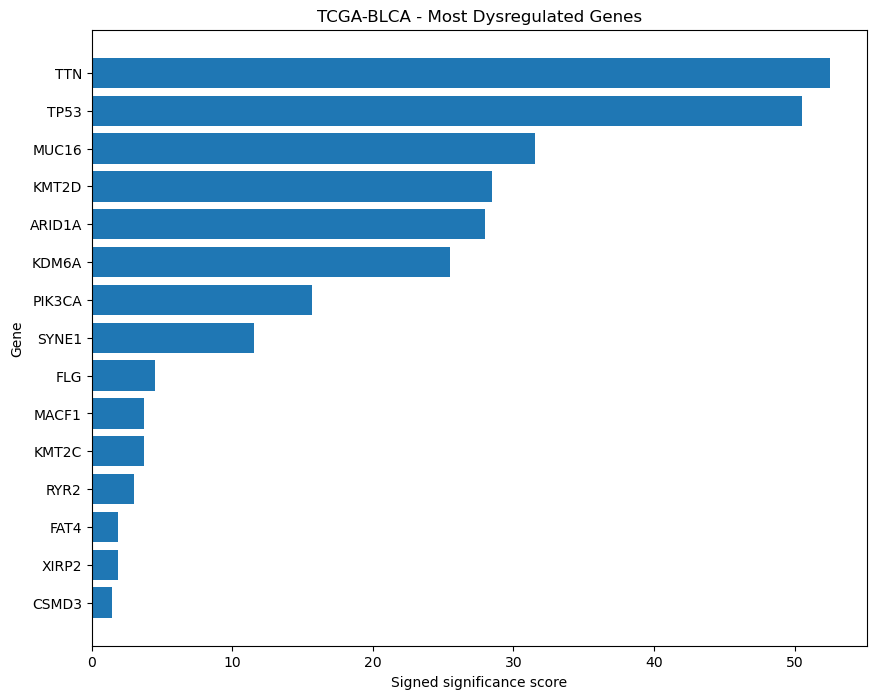

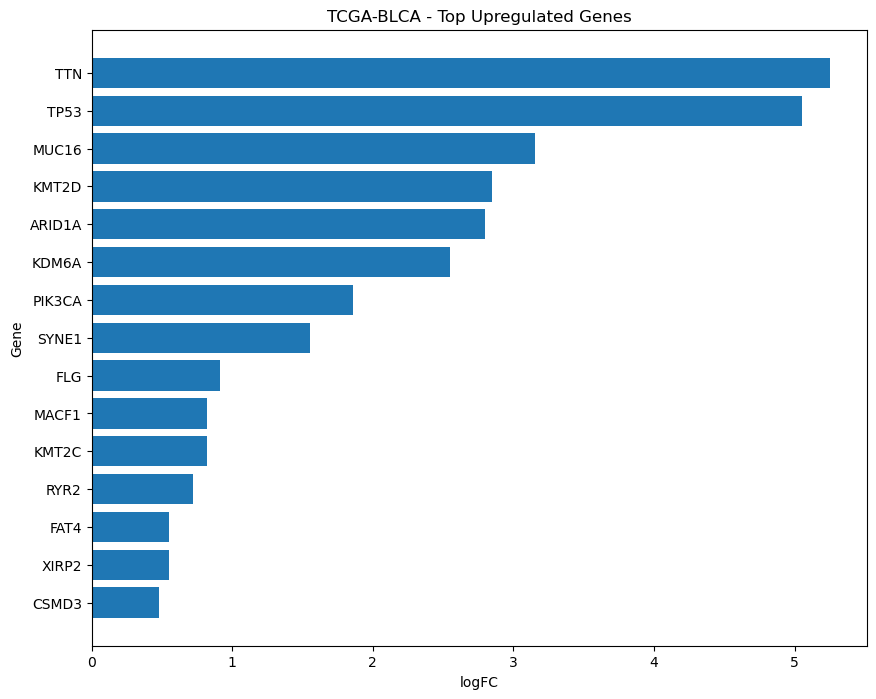

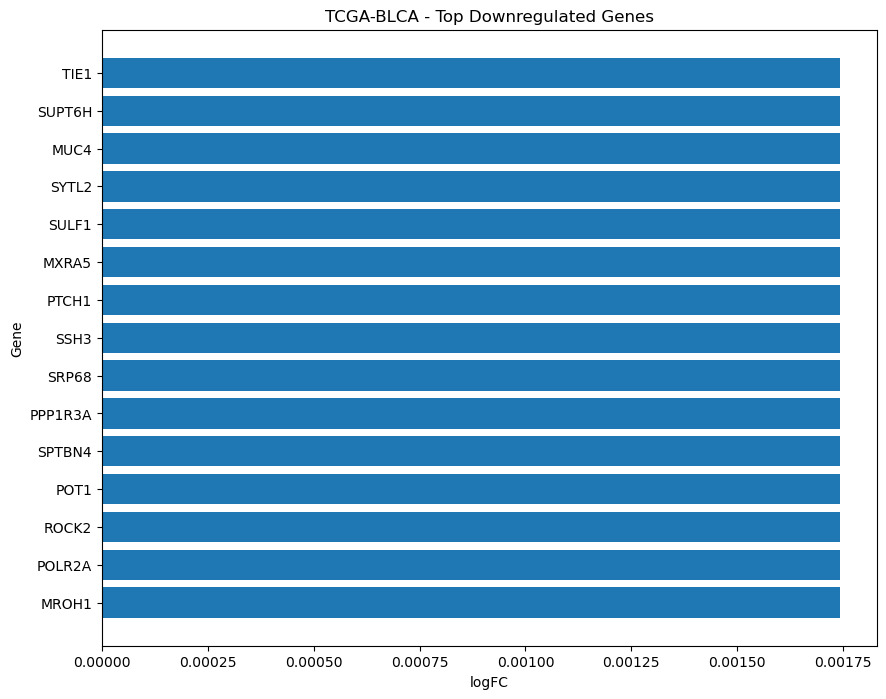


=== TCGA-BRCA ===
[cache] file IDs: TCGA-BRCA


[cache] mutation matrix: TCGA-BRCA
[cache] mutation scores: TCGA-BRCA


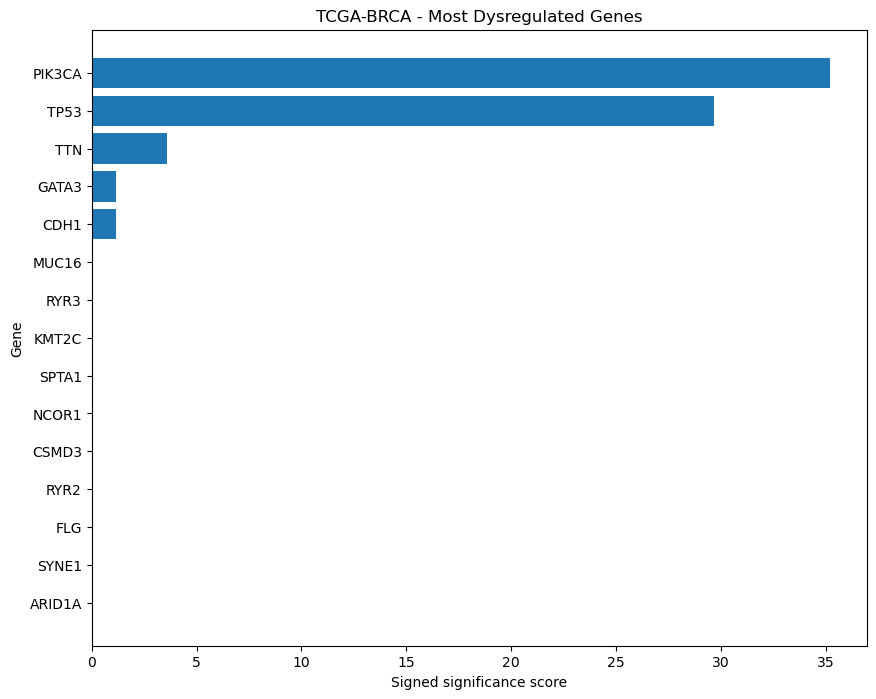

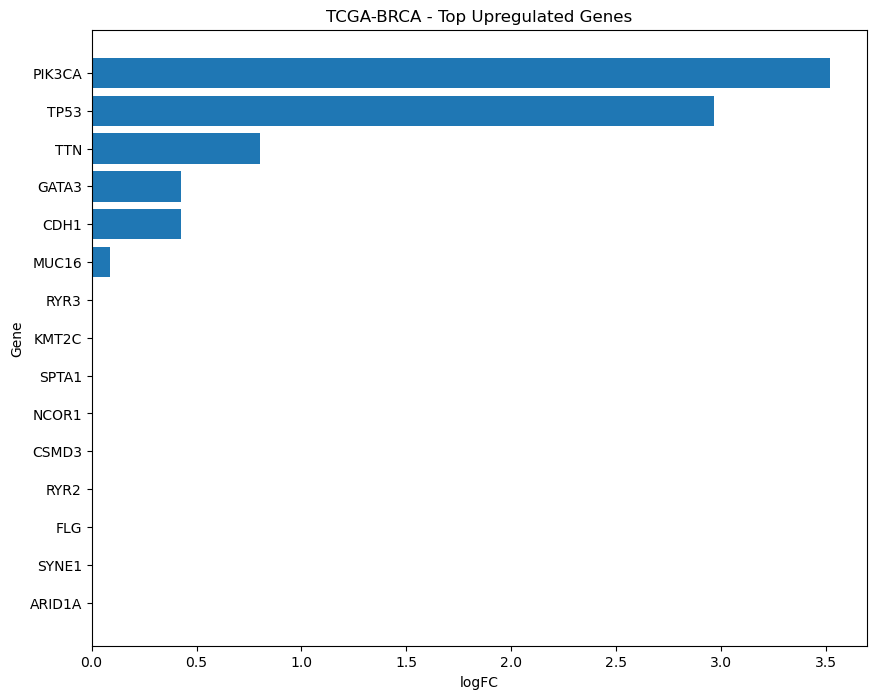

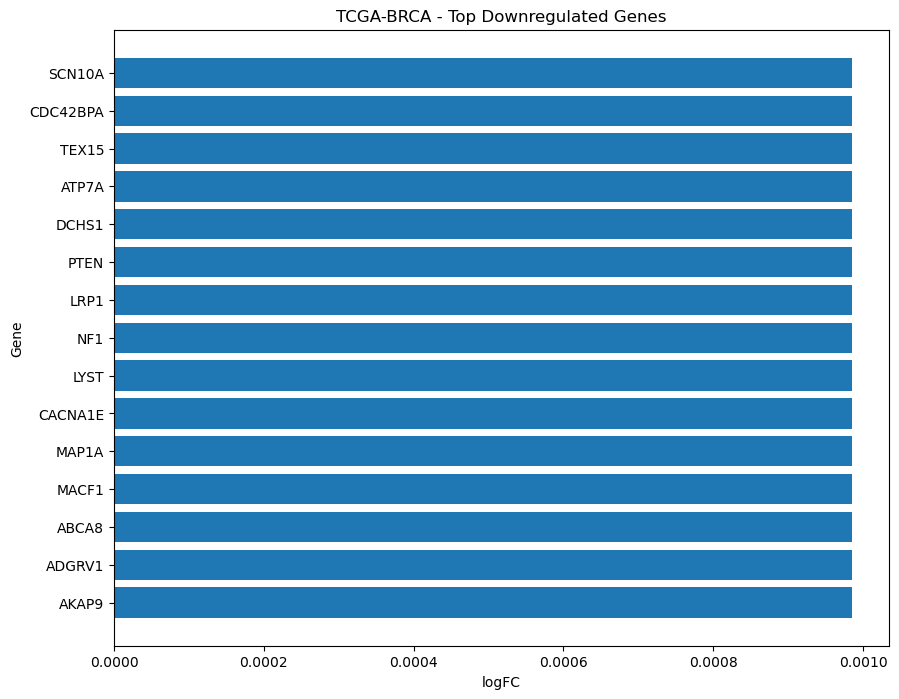


=== TCGA-CESC ===
[cache] file IDs: TCGA-CESC


[cache] mutation matrix: TCGA-CESC
[cache] mutation scores: TCGA-CESC


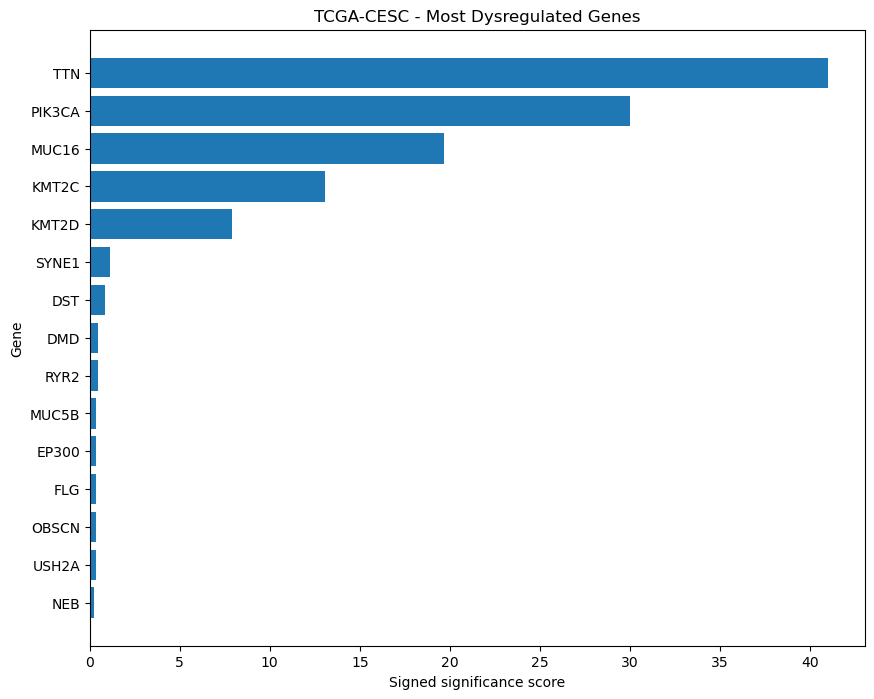

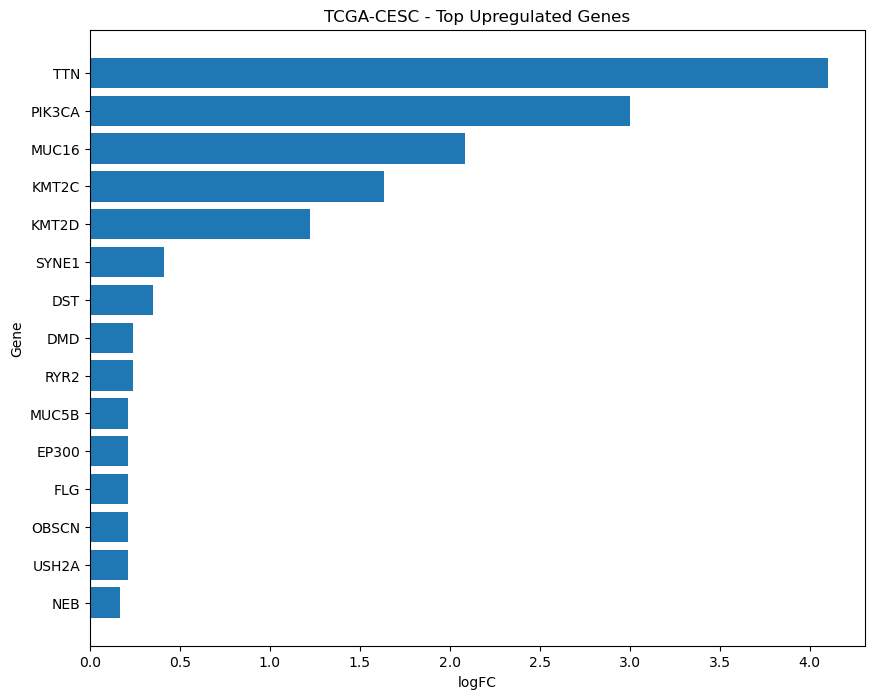

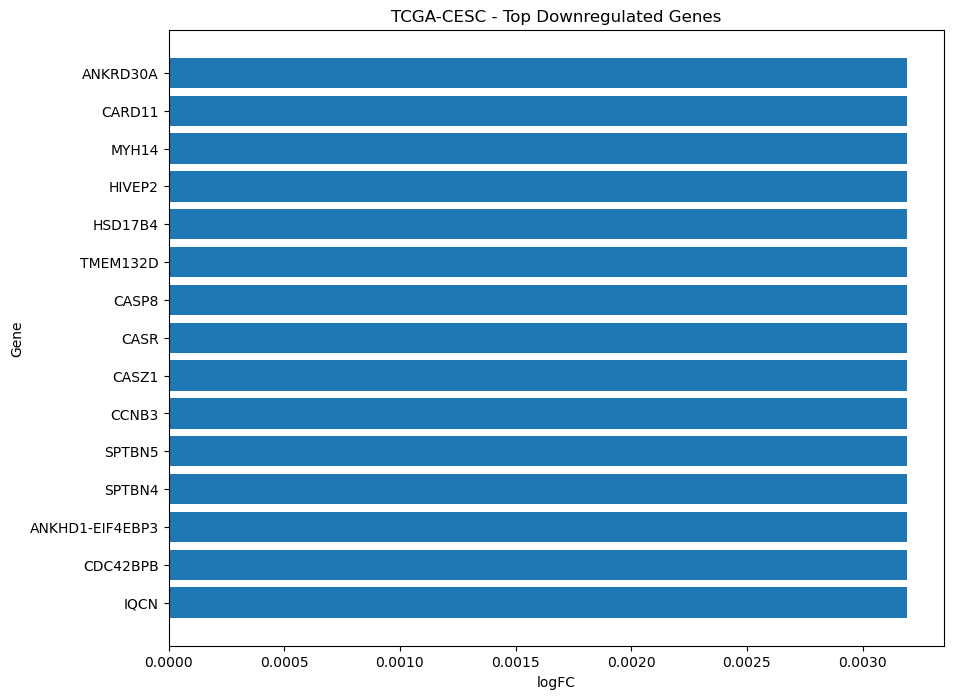


=== TCGA-COAD ===
[cache] file IDs: TCGA-COAD


[cache] mutation matrix: TCGA-COAD
[cache] mutation scores: TCGA-COAD


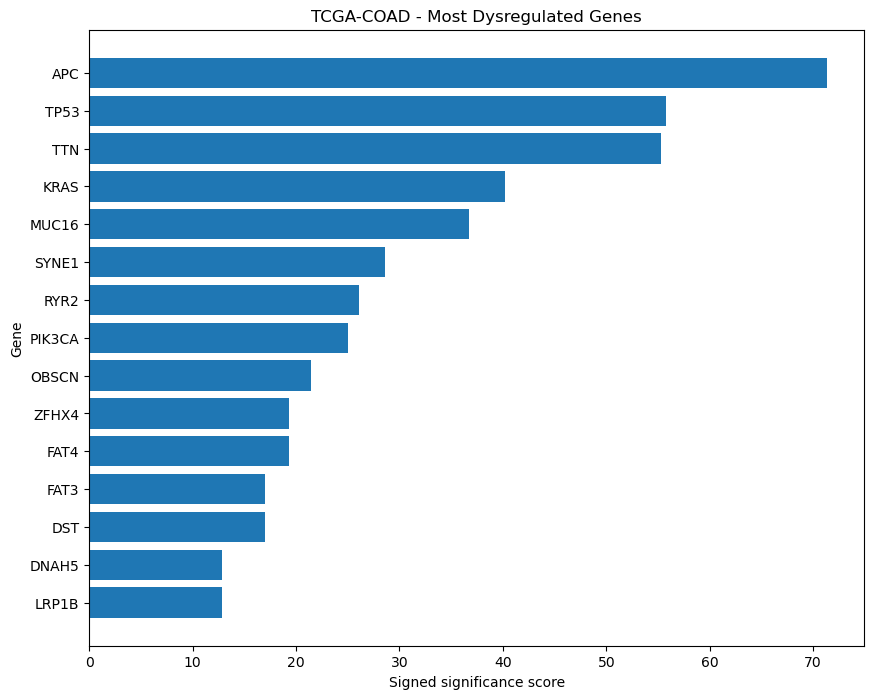

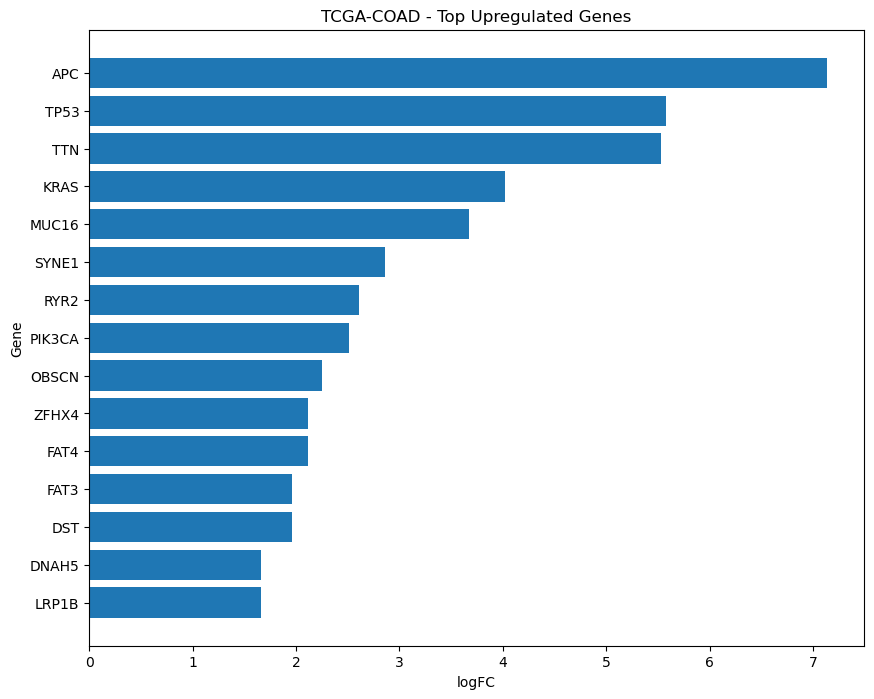

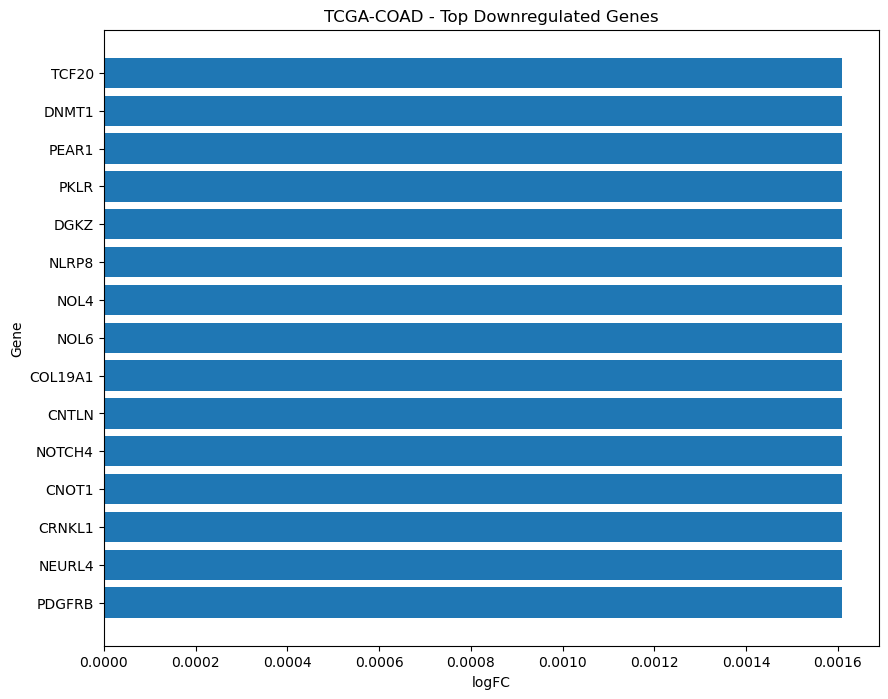


=== TCGA-ESCA ===
[cache] file IDs: TCGA-ESCA


[cache] mutation matrix: TCGA-ESCA
[cache] mutation scores: TCGA-ESCA


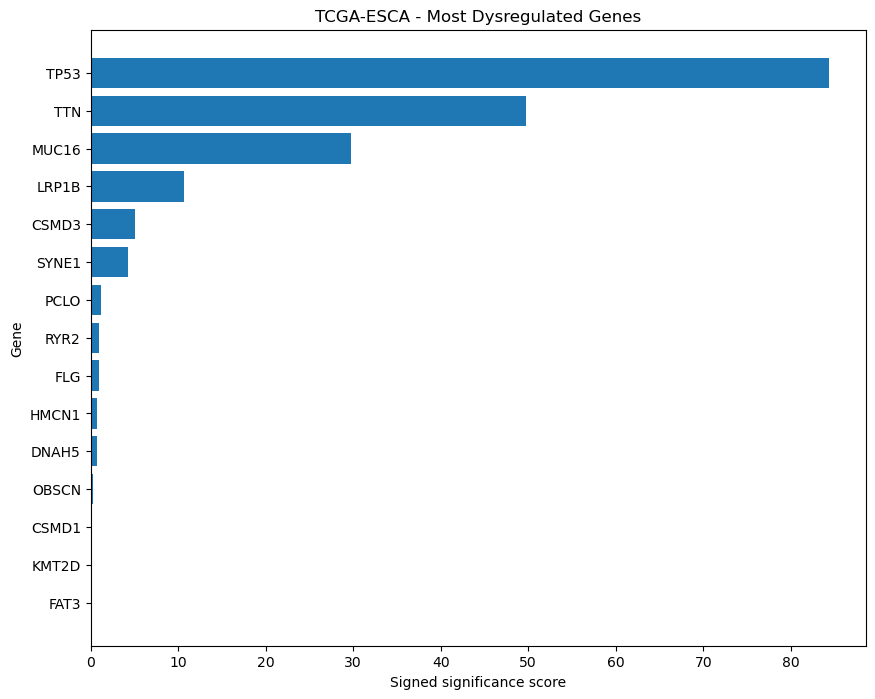

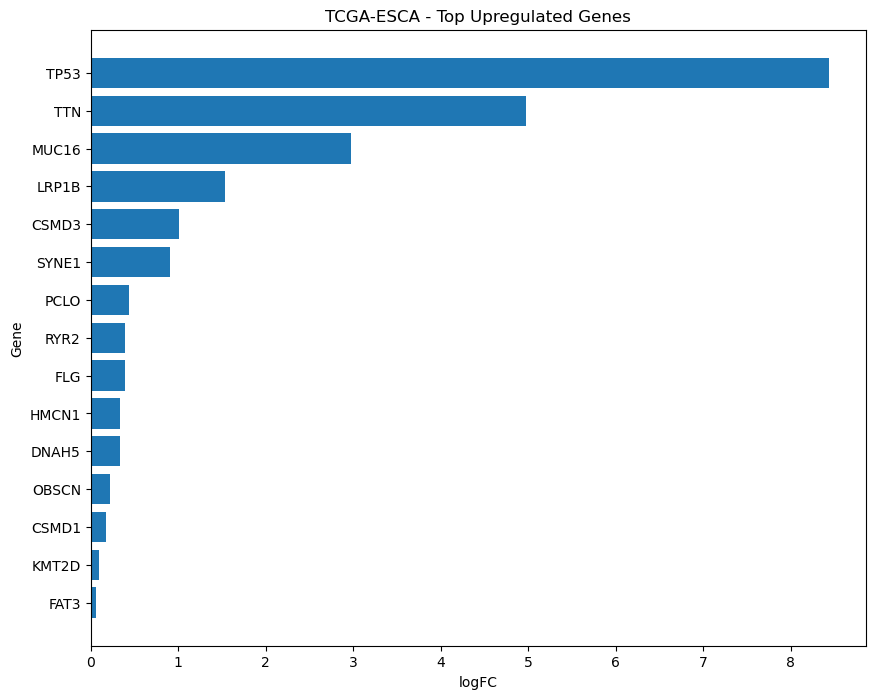

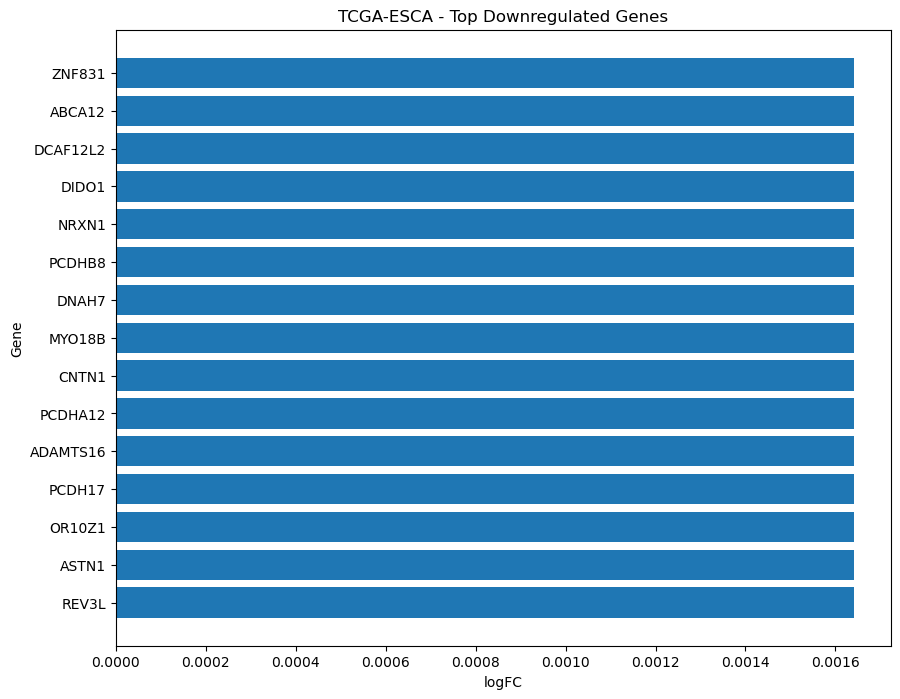


=== TCGA-GBM ===
[cache] file IDs: TCGA-GBM


[cache] mutation matrix: TCGA-GBM
[cache] mutation scores: TCGA-GBM


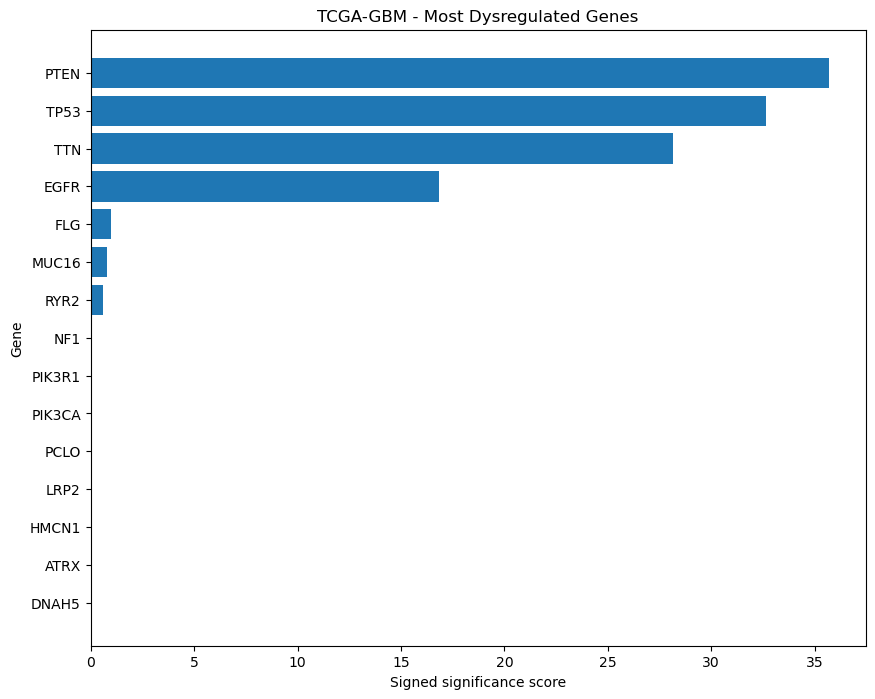

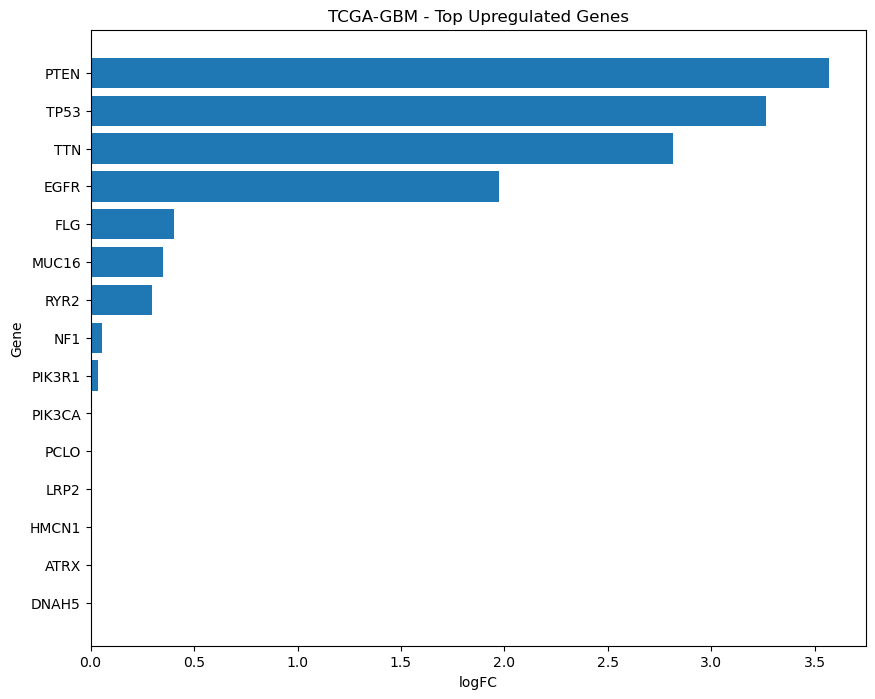

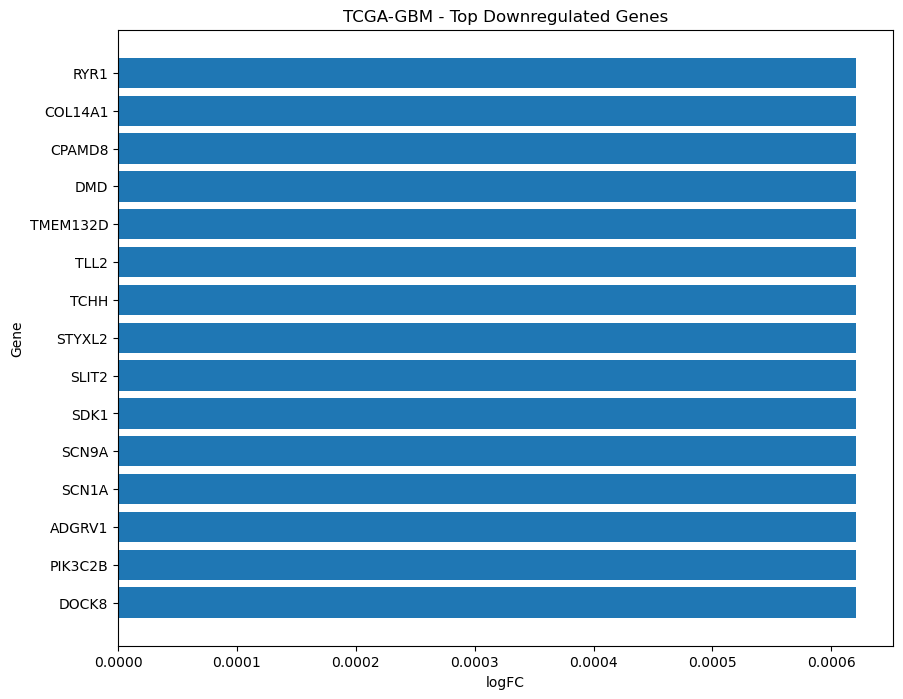


=== TCGA-HNSC ===
[cache] file IDs: TCGA-HNSC


[cache] mutation matrix: TCGA-HNSC
[cache] mutation scores: TCGA-HNSC


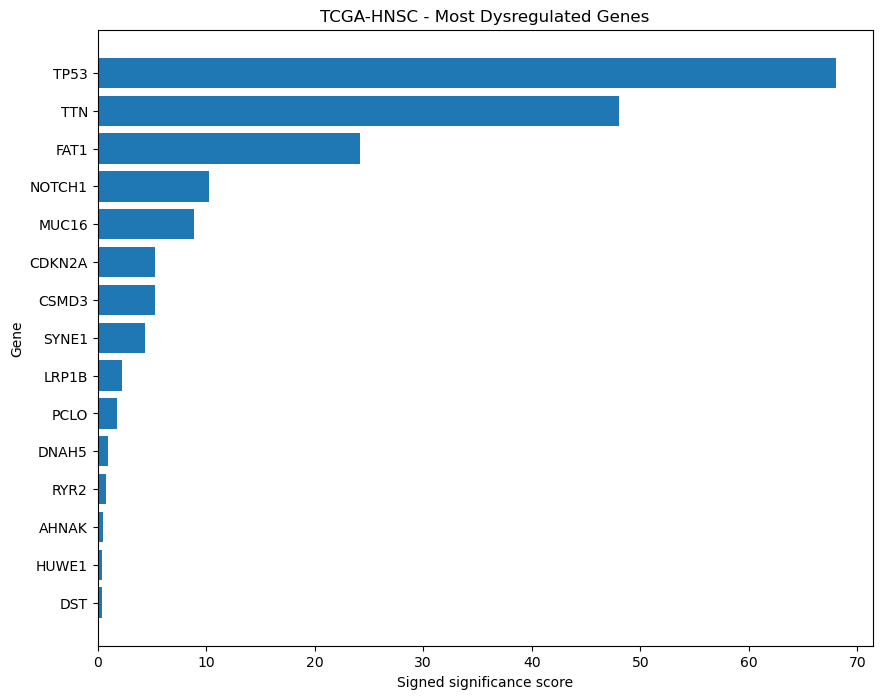

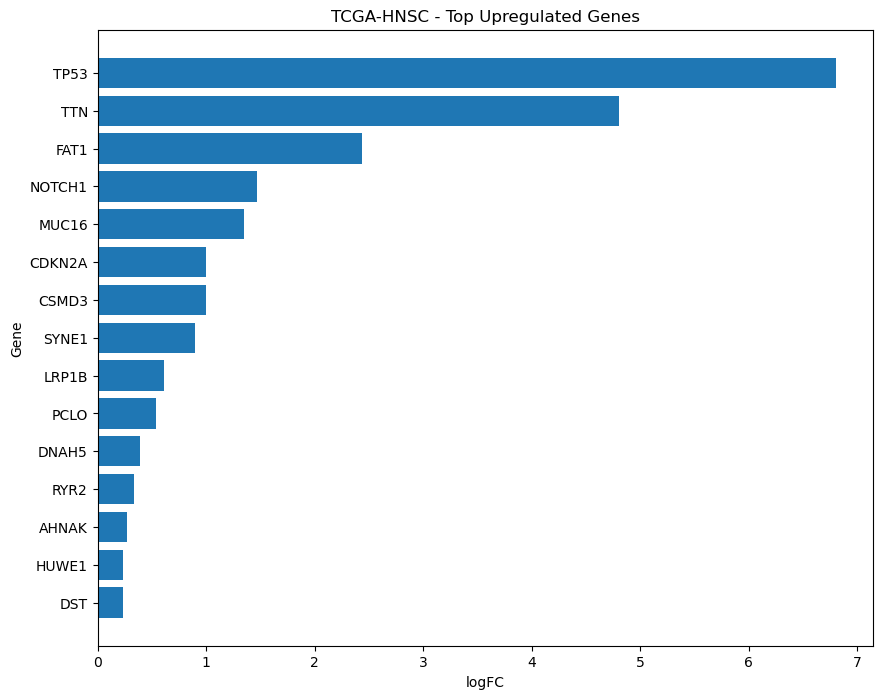

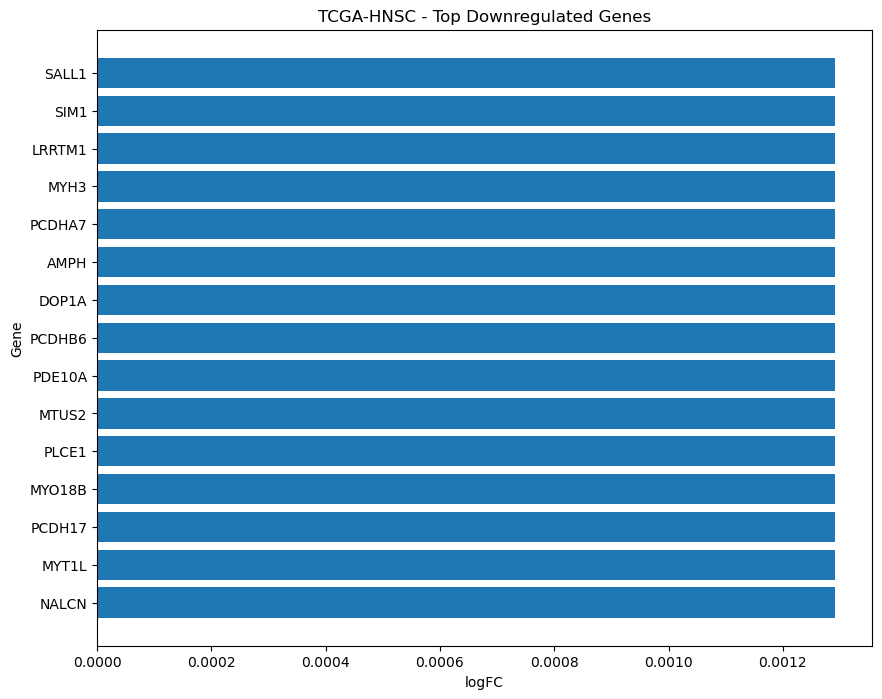


=== TCGA-KIRC ===
[cache] file IDs: TCGA-KIRC


[cache] mutation matrix: TCGA-KIRC
[cache] mutation scores: TCGA-KIRC


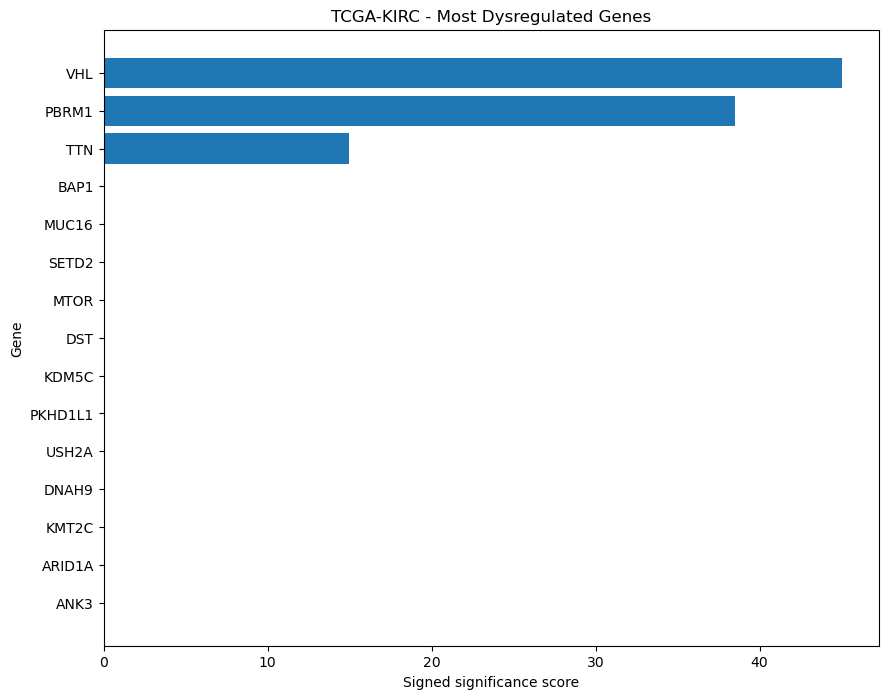

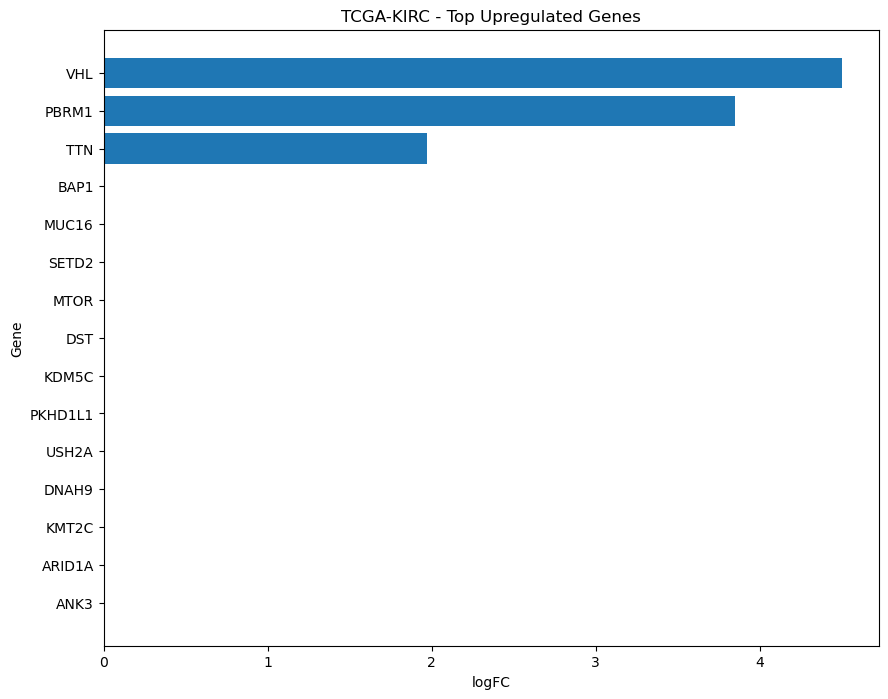

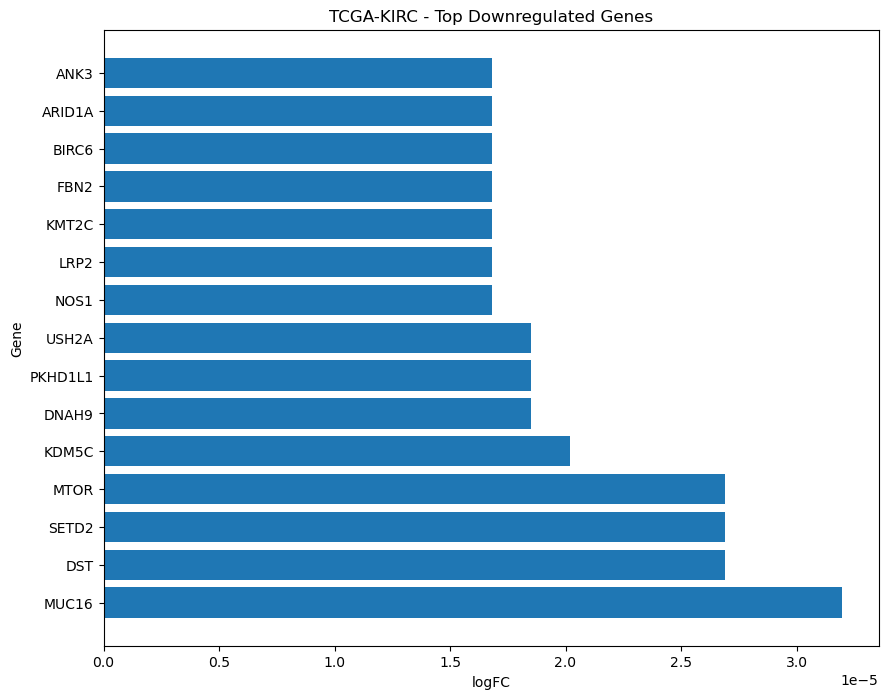


=== TCGA-KIRP ===
[cache] file IDs: TCGA-KIRP


[cache] mutation matrix: TCGA-KIRP
[cache] mutation scores: TCGA-KIRP


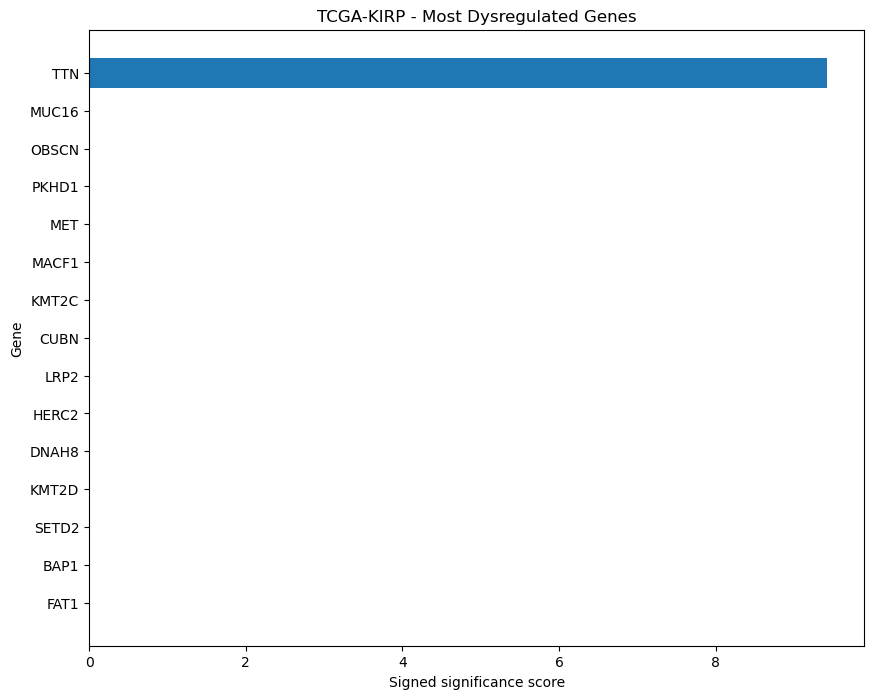

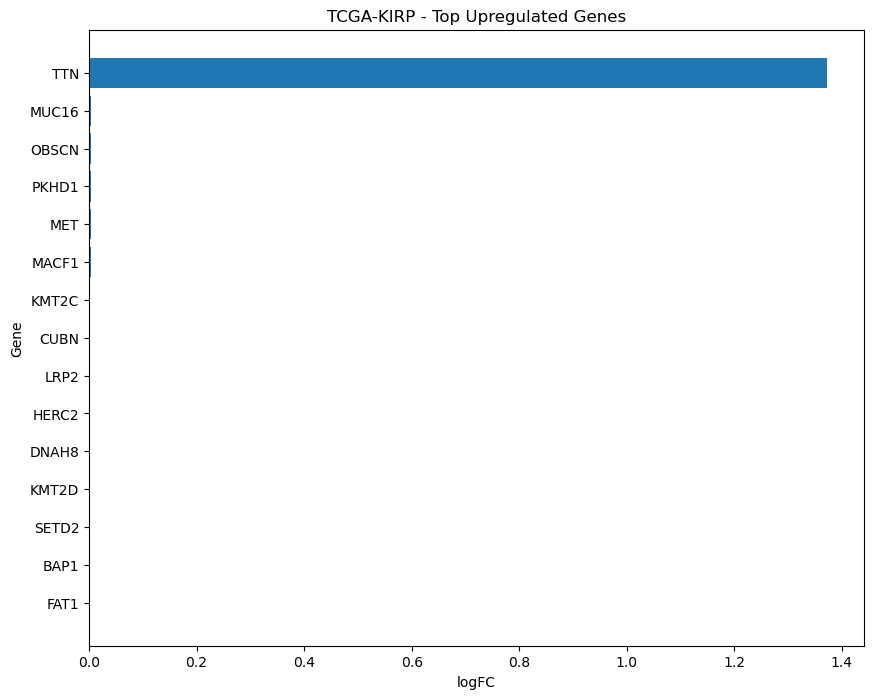

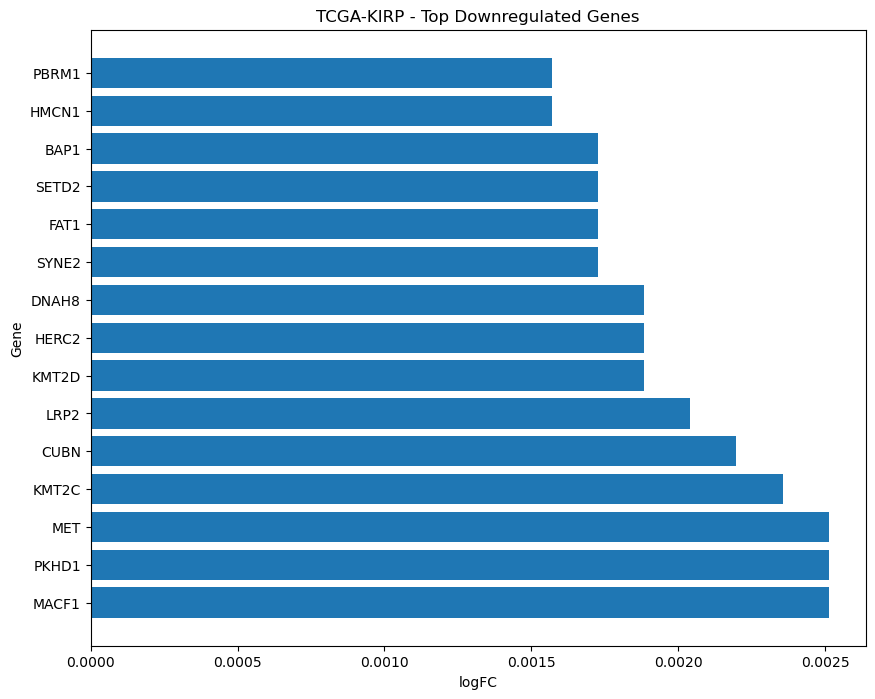


=== TCGA-LAML ===
[cache] file IDs: TCGA-LAML


[cache] mutation matrix: TCGA-LAML
[cache] mutation scores: TCGA-LAML


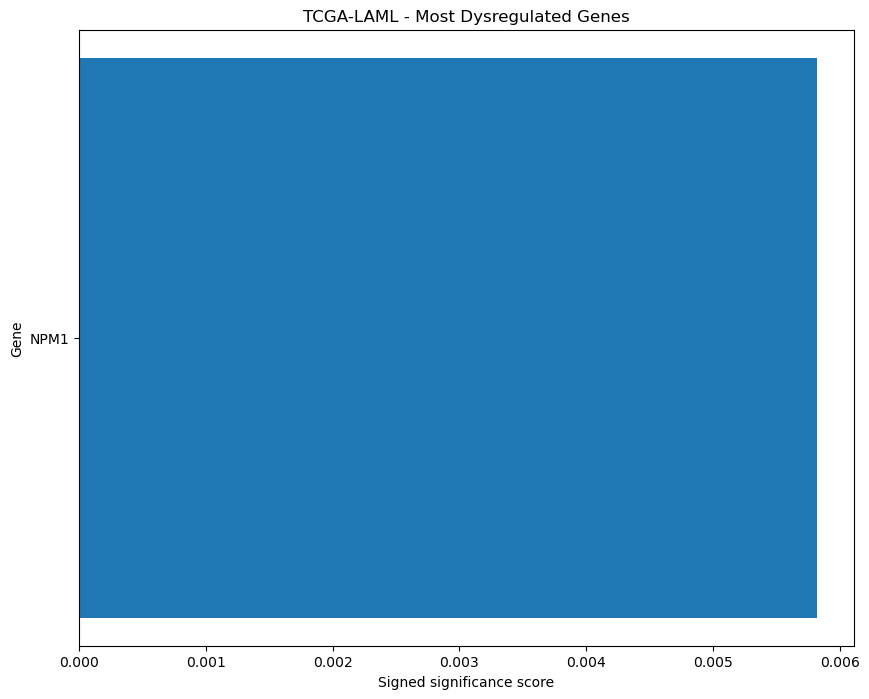

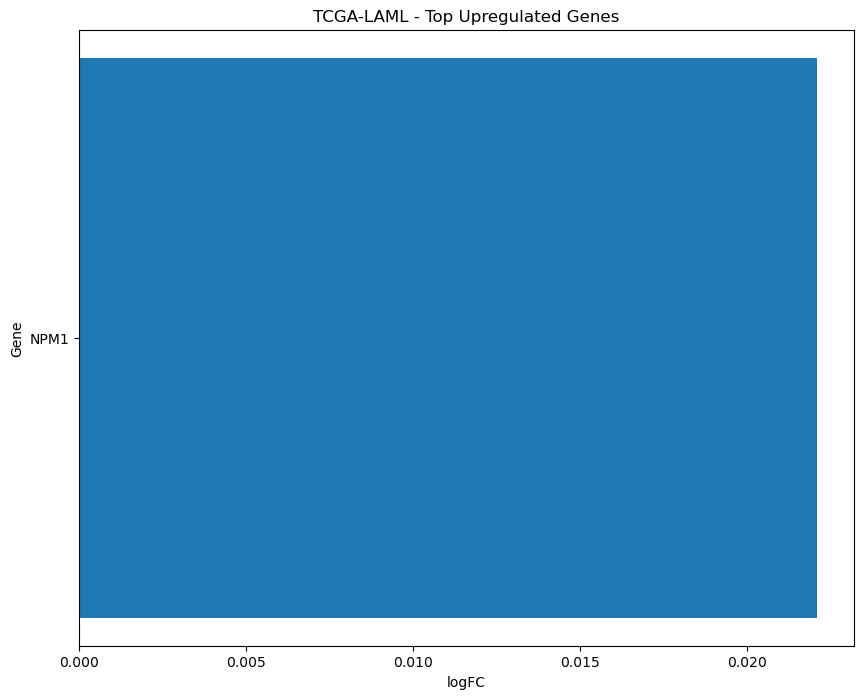

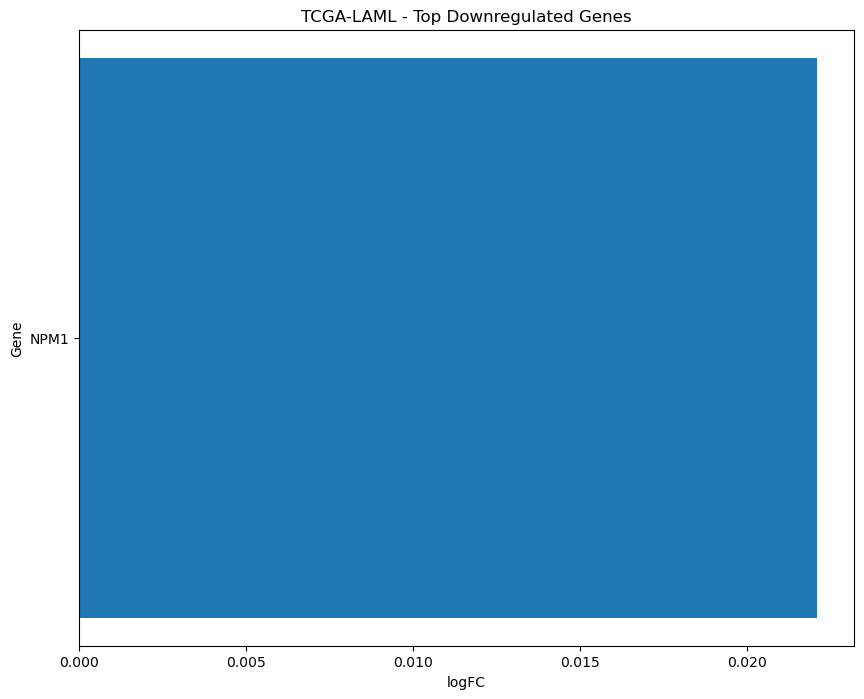


=== TCGA-LGG ===
[cache] file IDs: TCGA-LGG


[cache] mutation matrix: TCGA-LGG
[cache] mutation scores: TCGA-LGG


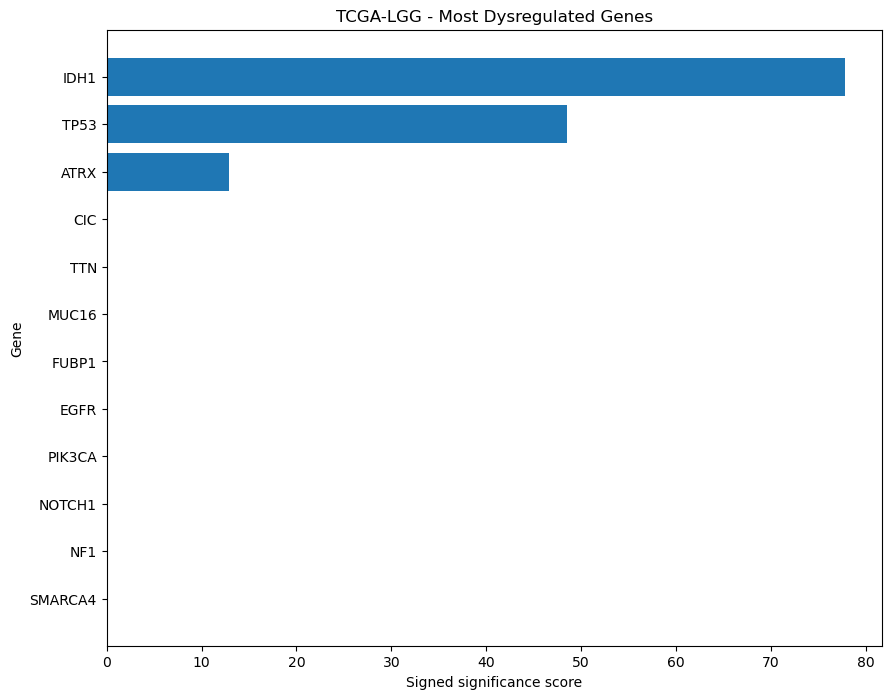

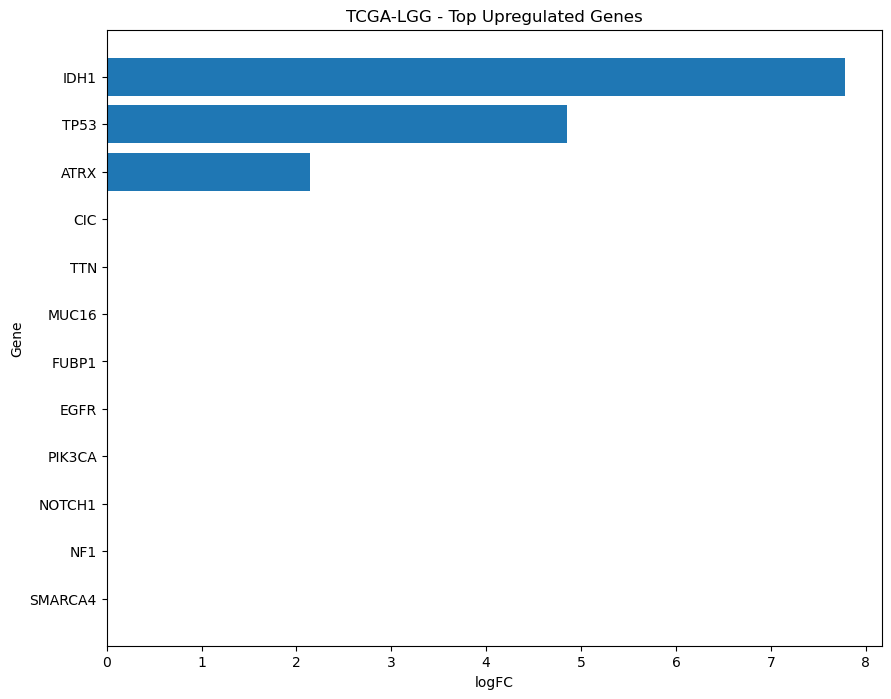

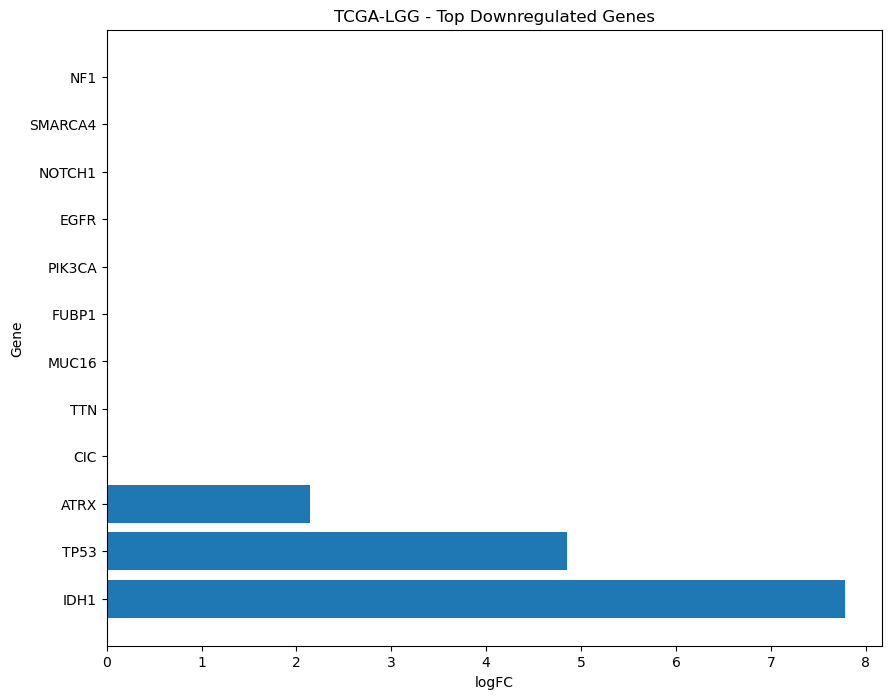


=== TCGA-LIHC ===
[cache] file IDs: TCGA-LIHC


[cache] mutation matrix: TCGA-LIHC
[cache] mutation scores: TCGA-LIHC


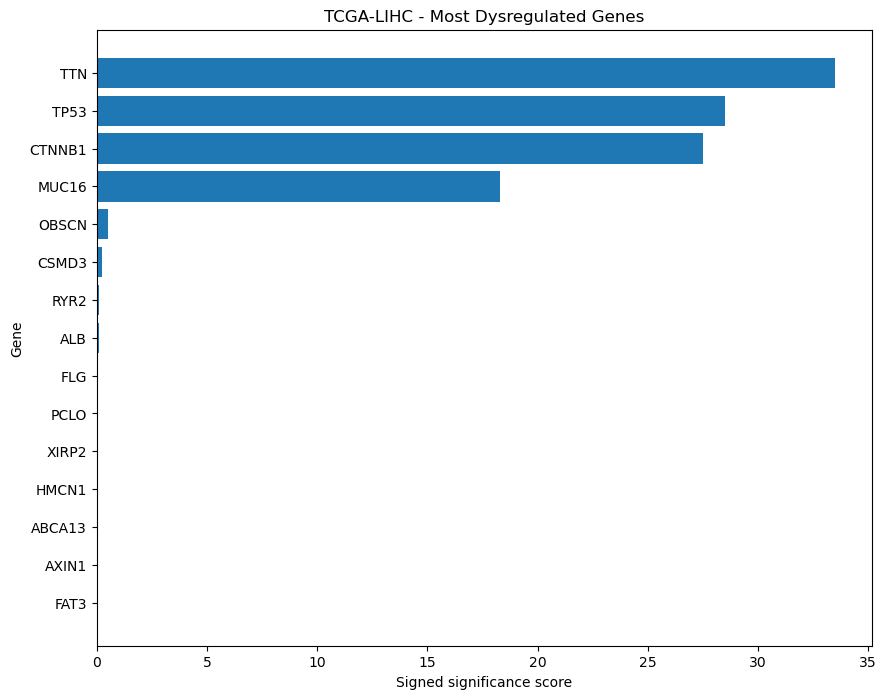

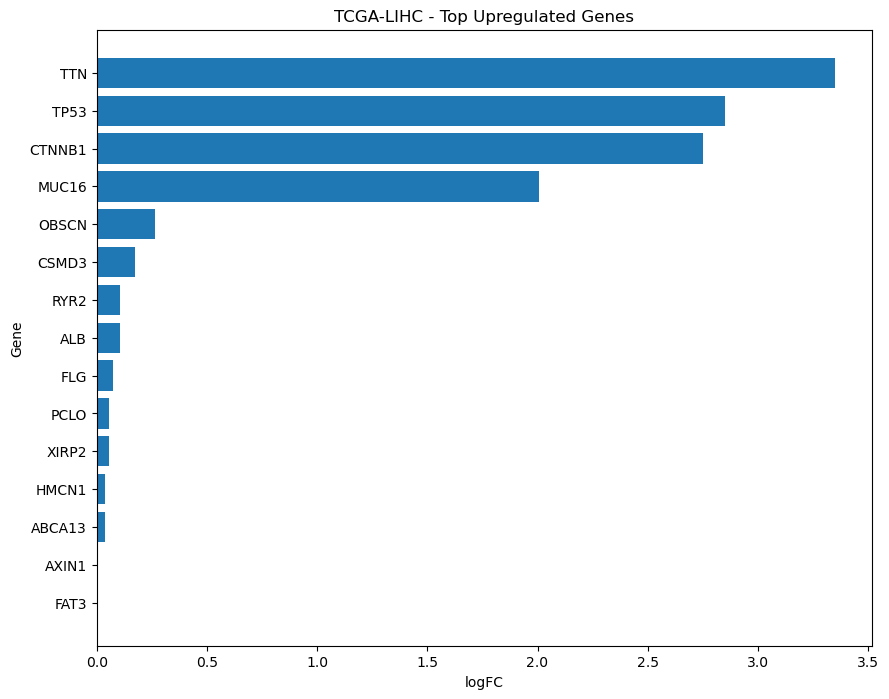

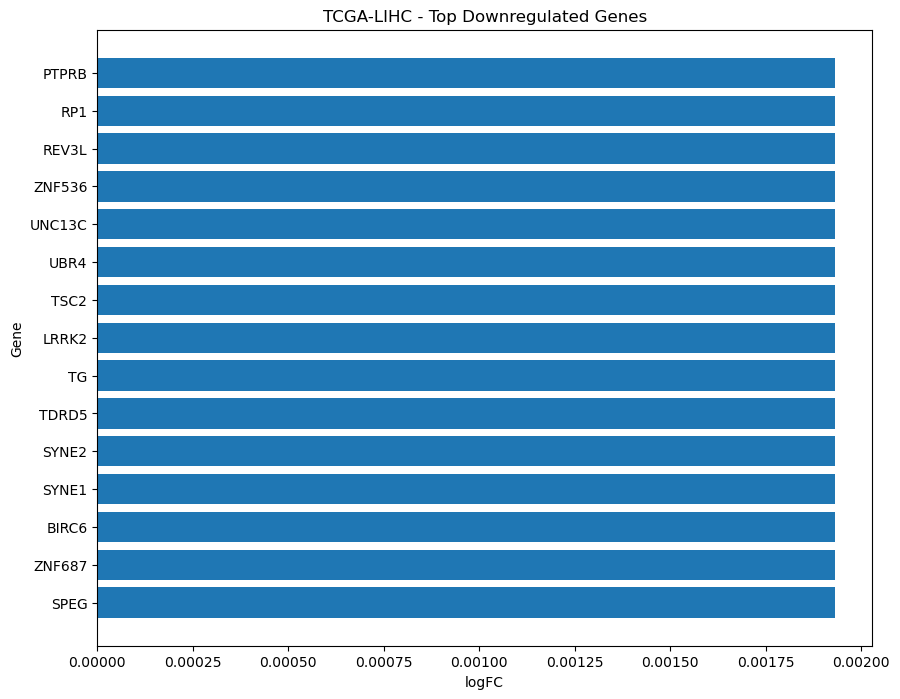


=== TCGA-LUAD ===
[cache] file IDs: TCGA-LUAD


[cache] mutation matrix: TCGA-LUAD
[cache] mutation scores: TCGA-LUAD


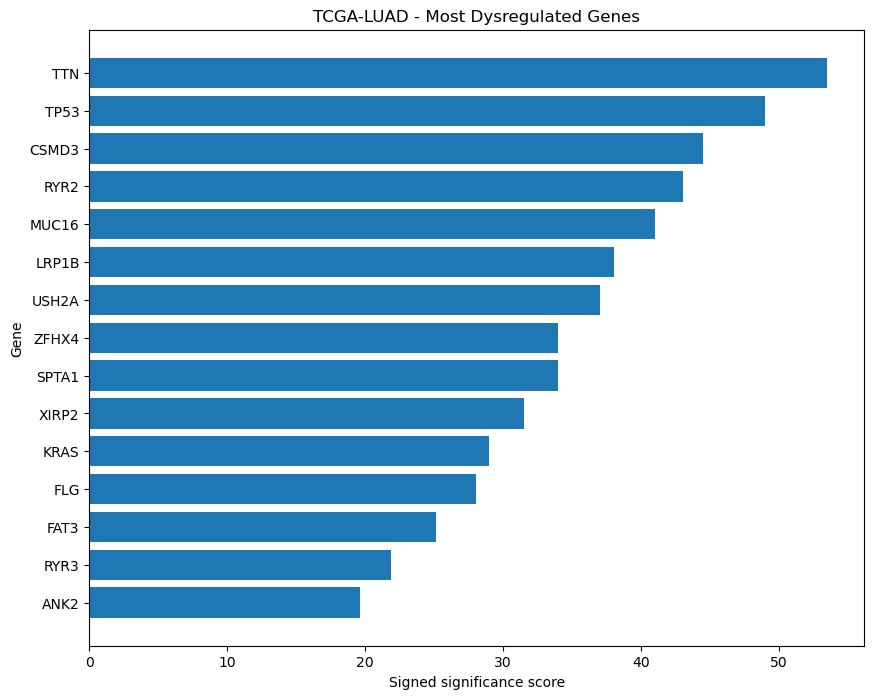

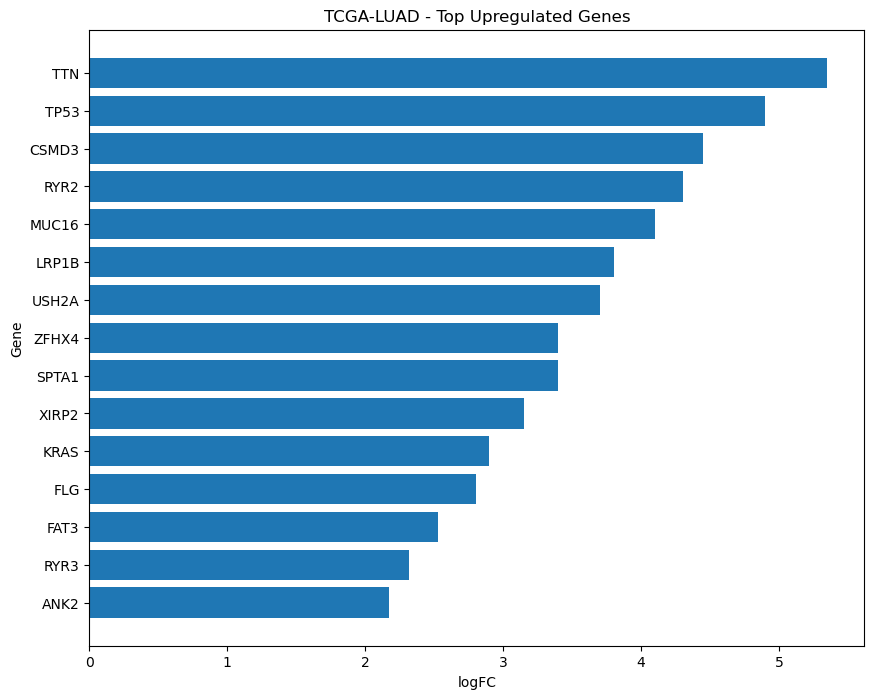

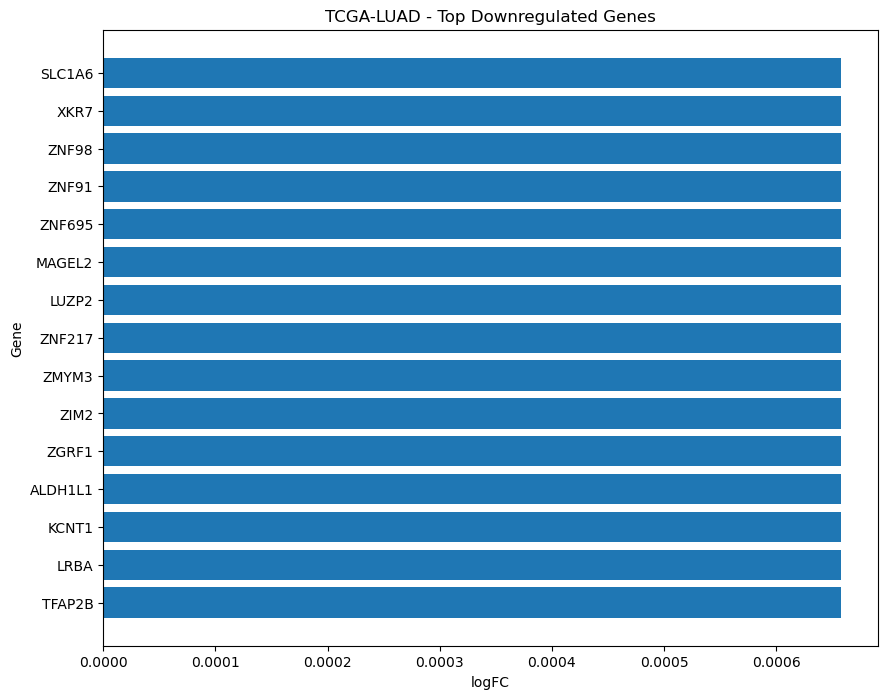


=== TCGA-LUSC ===
[cache] file IDs: TCGA-LUSC


[cache] mutation matrix: TCGA-LUSC
[cache] mutation scores: TCGA-LUSC


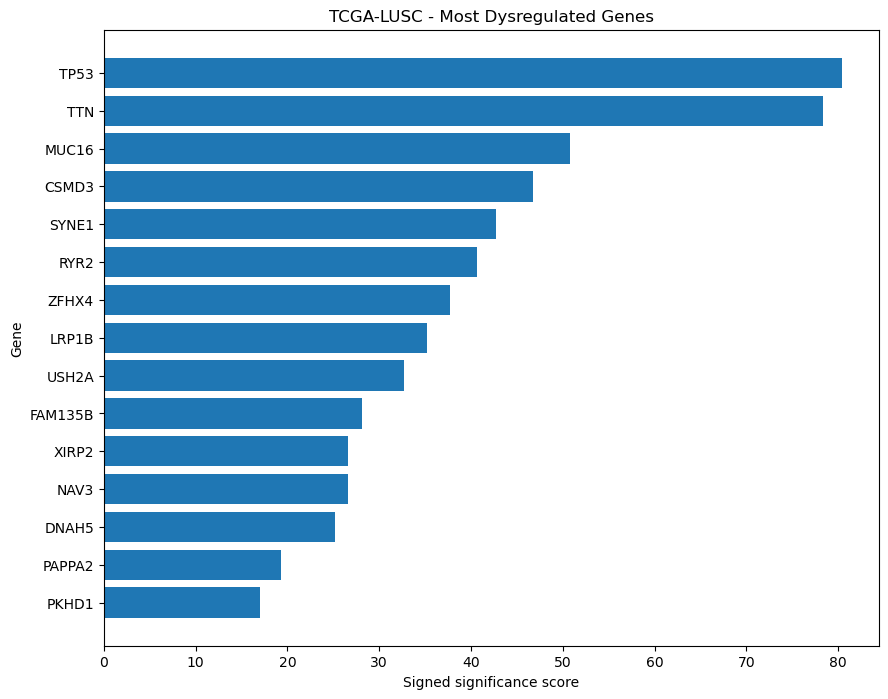

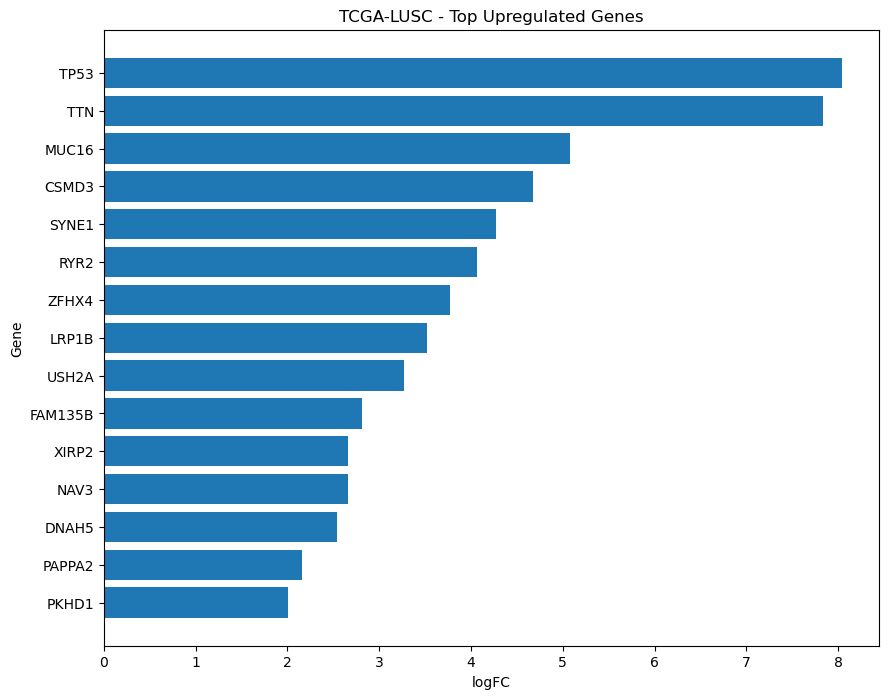

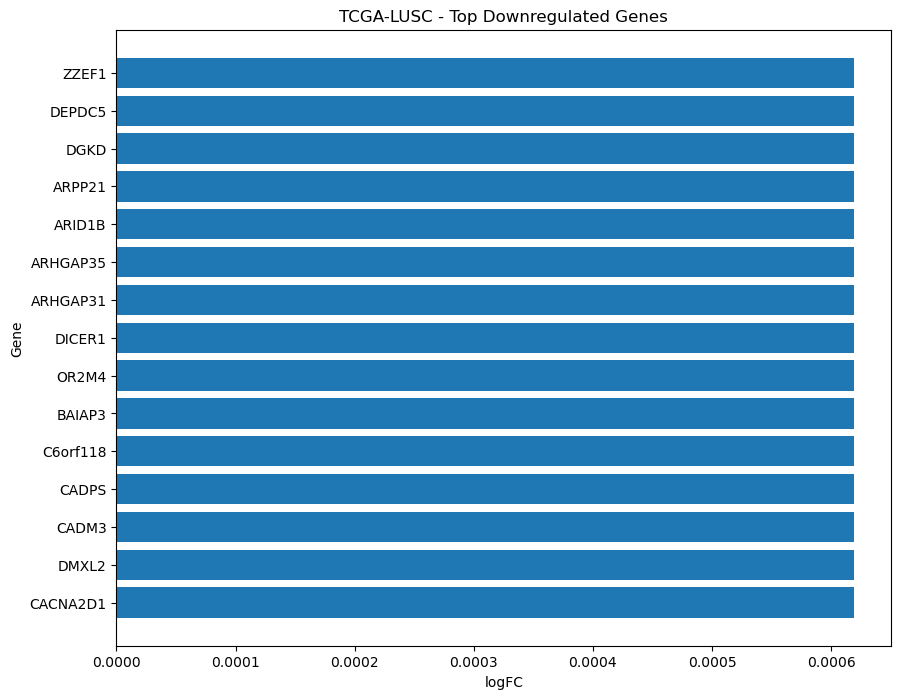


=== TCGA-OV ===
[cache] file IDs: TCGA-OV


[cache] mutation matrix: TCGA-OV
[cache] mutation scores: TCGA-OV


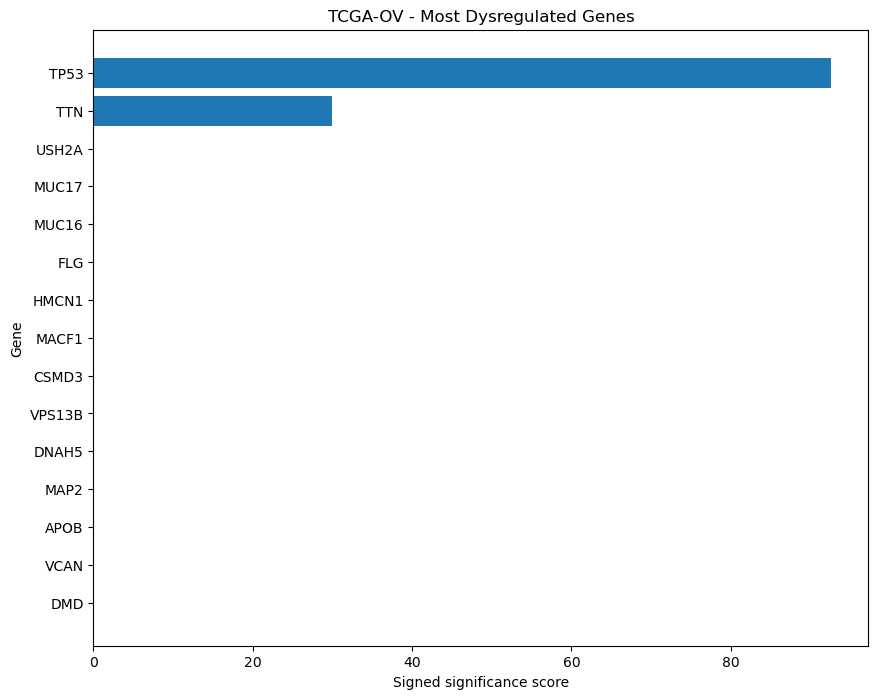

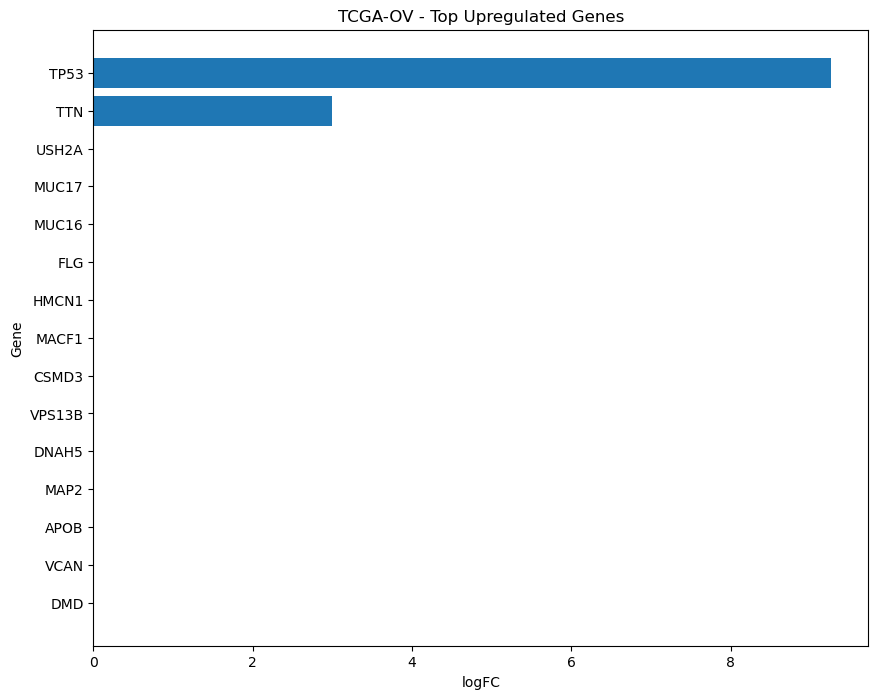

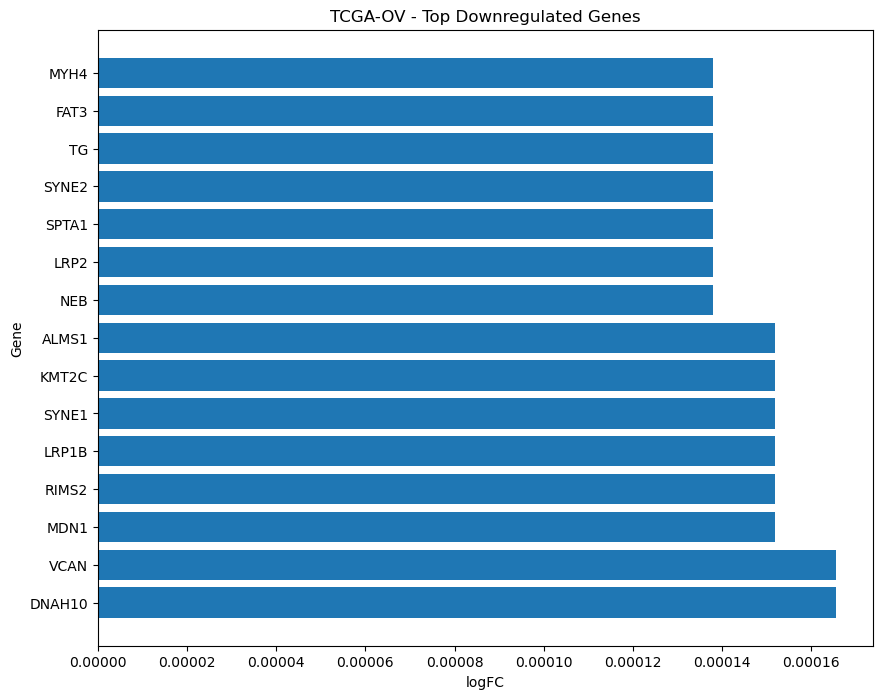


=== TCGA-PAAD ===
[cache] file IDs: TCGA-PAAD


[cache] mutation matrix: TCGA-PAAD
[cache] mutation scores: TCGA-PAAD


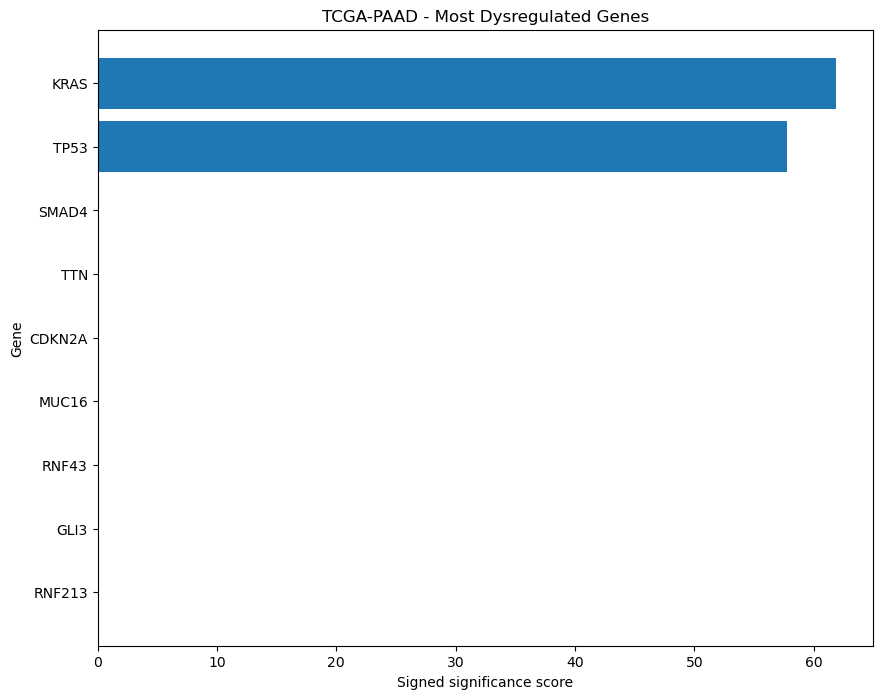

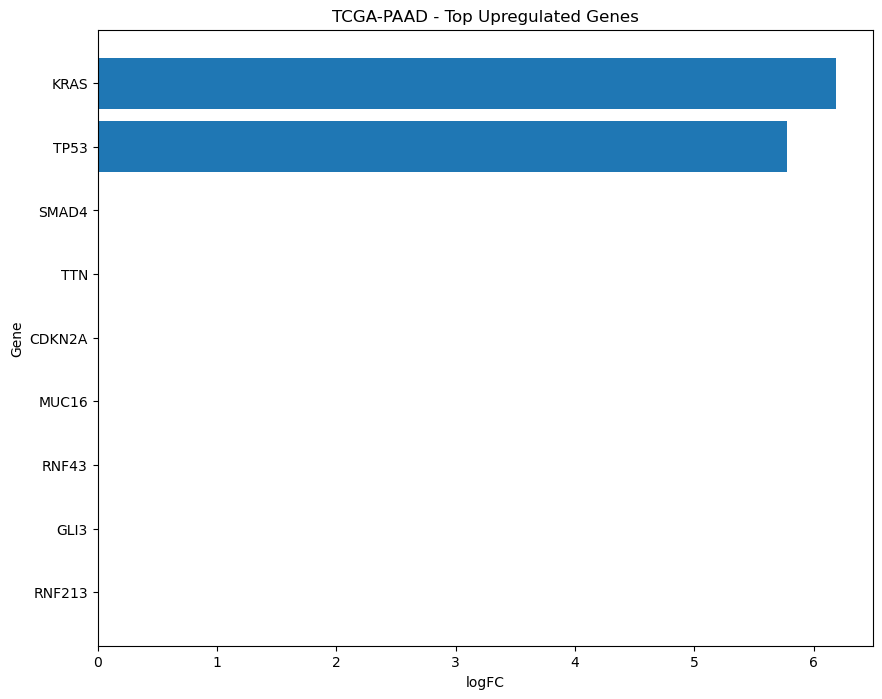

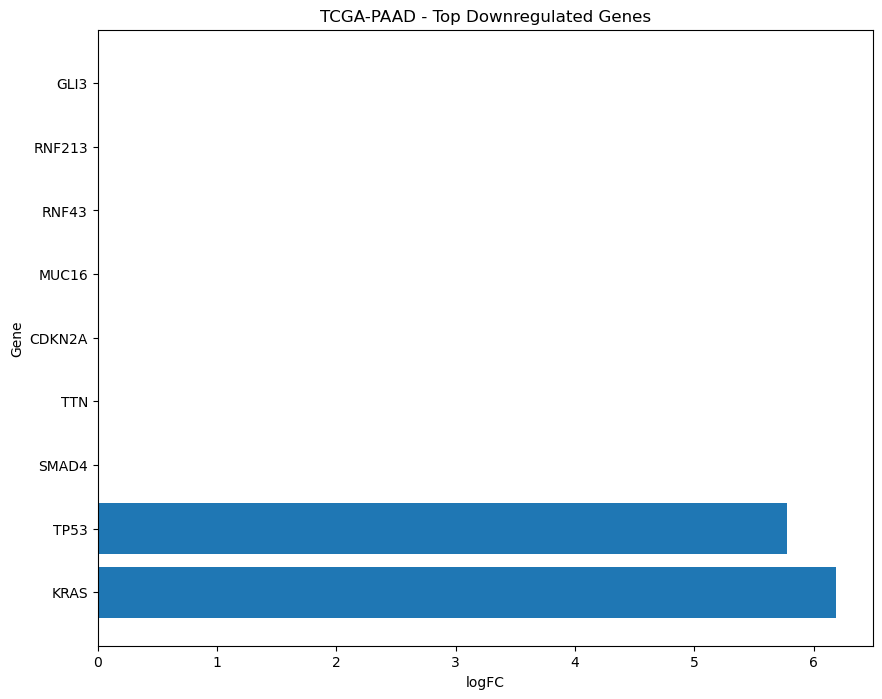


=== TCGA-PCPG ===
[cache] file IDs: TCGA-PCPG


[cache] mutation matrix: TCGA-PCPG
[cache] mutation scores: TCGA-PCPG


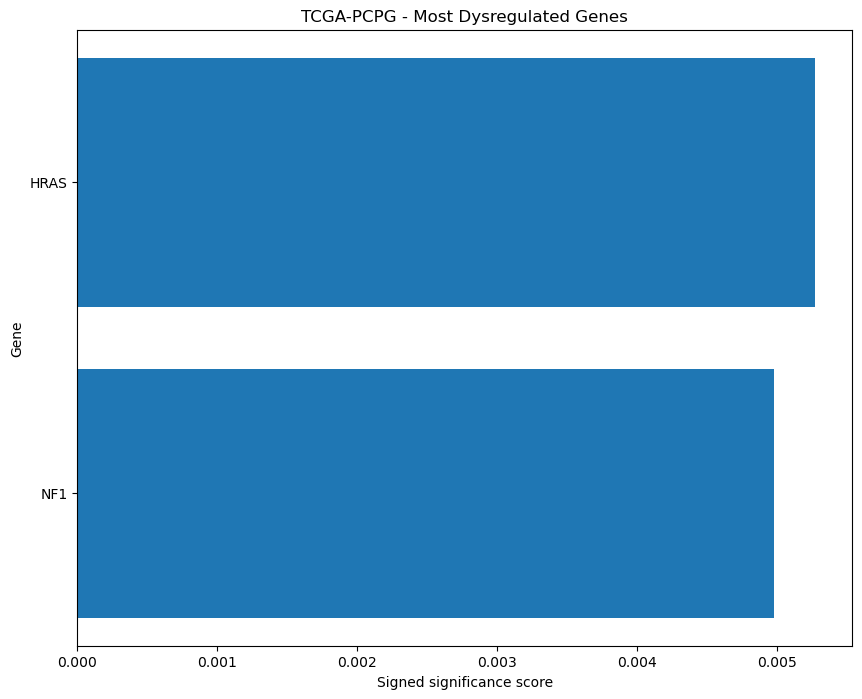

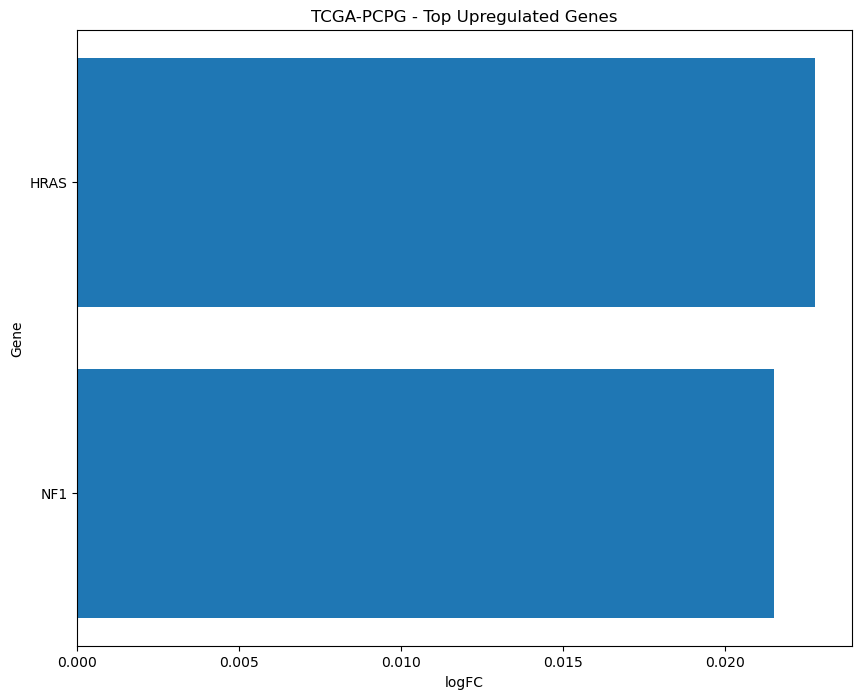

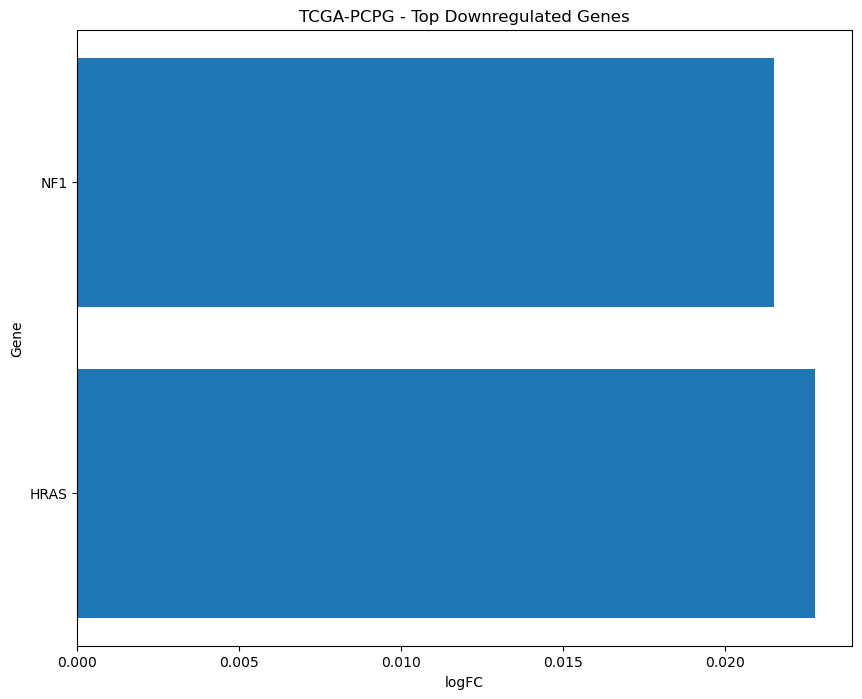


=== TCGA-PRAD ===
[cache] file IDs: TCGA-PRAD


[cache] mutation matrix: TCGA-PRAD
[cache] mutation scores: TCGA-PRAD


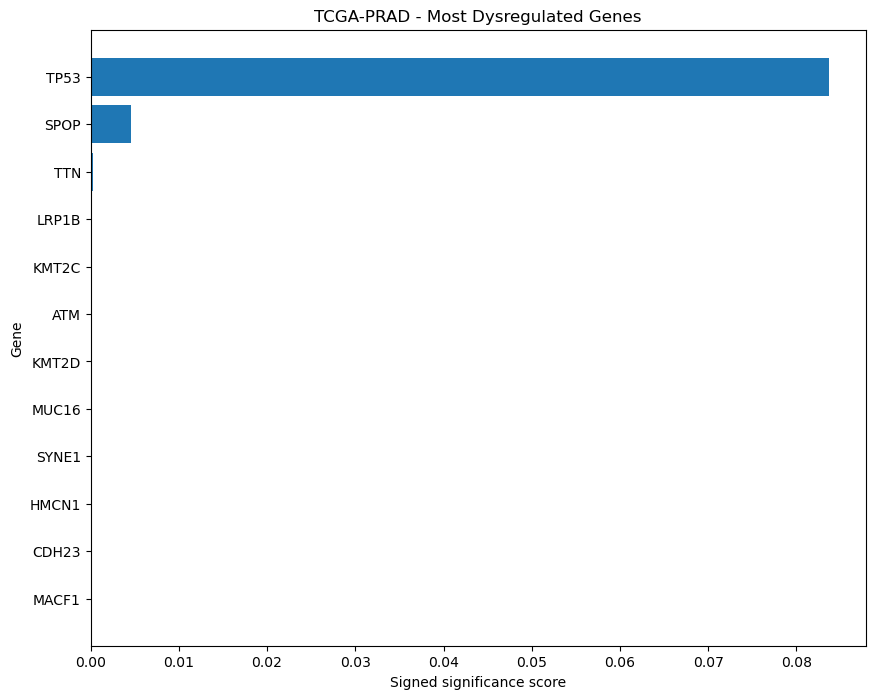

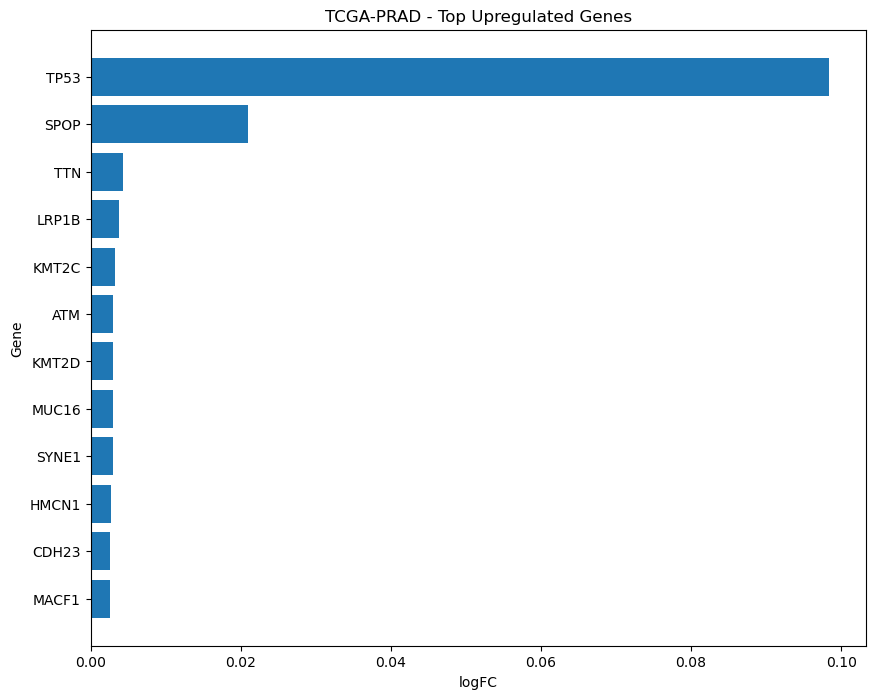

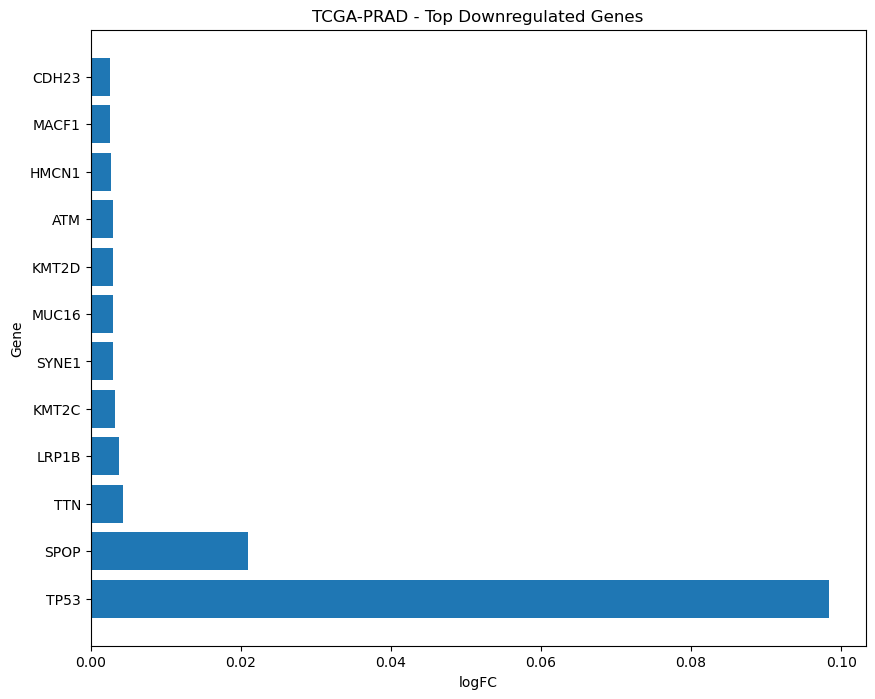


=== TCGA-READ ===
[cache] file IDs: TCGA-READ


[cache] mutation matrix: TCGA-READ
[cache] mutation scores: TCGA-READ


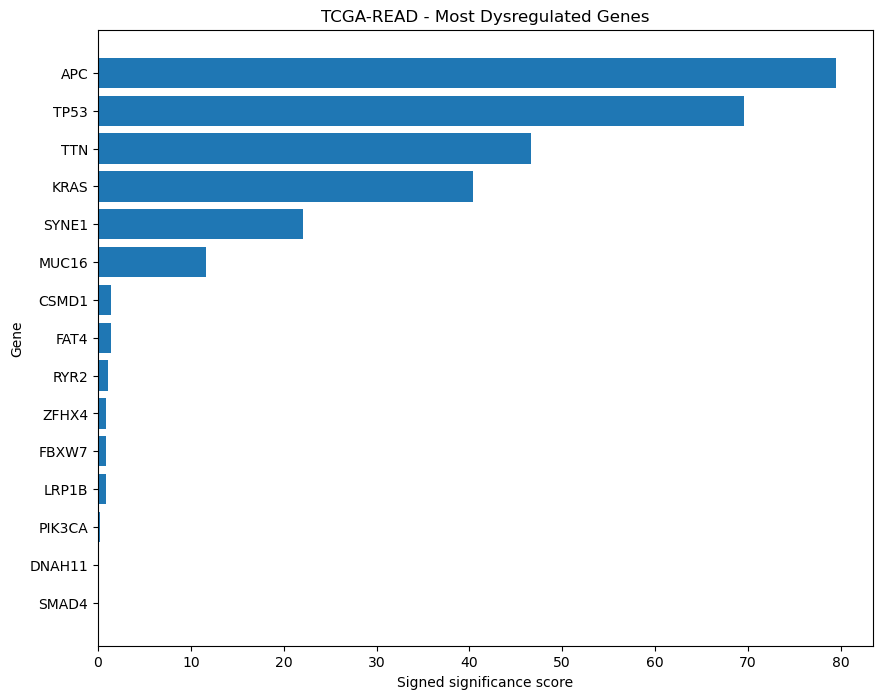

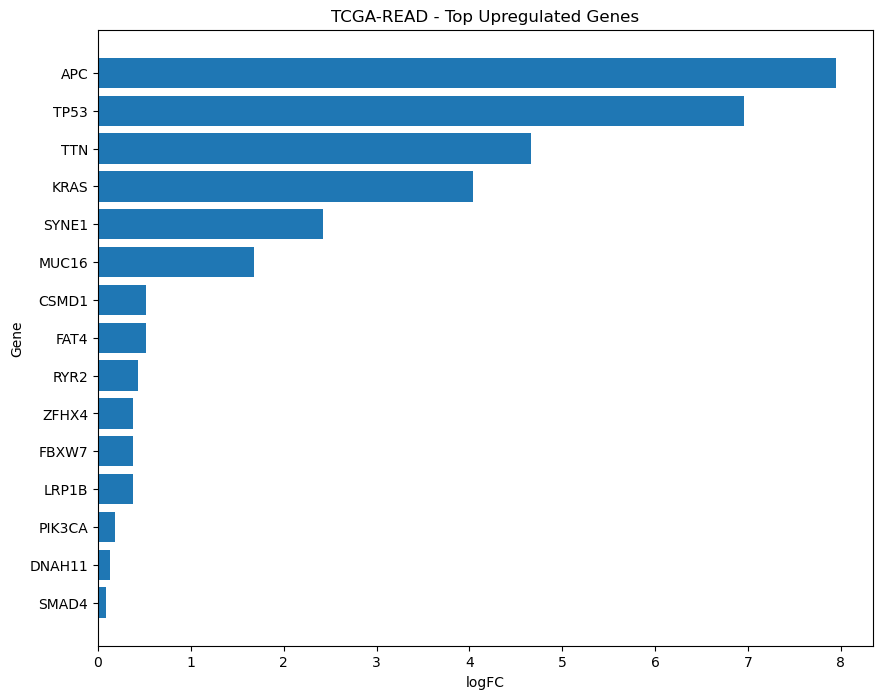

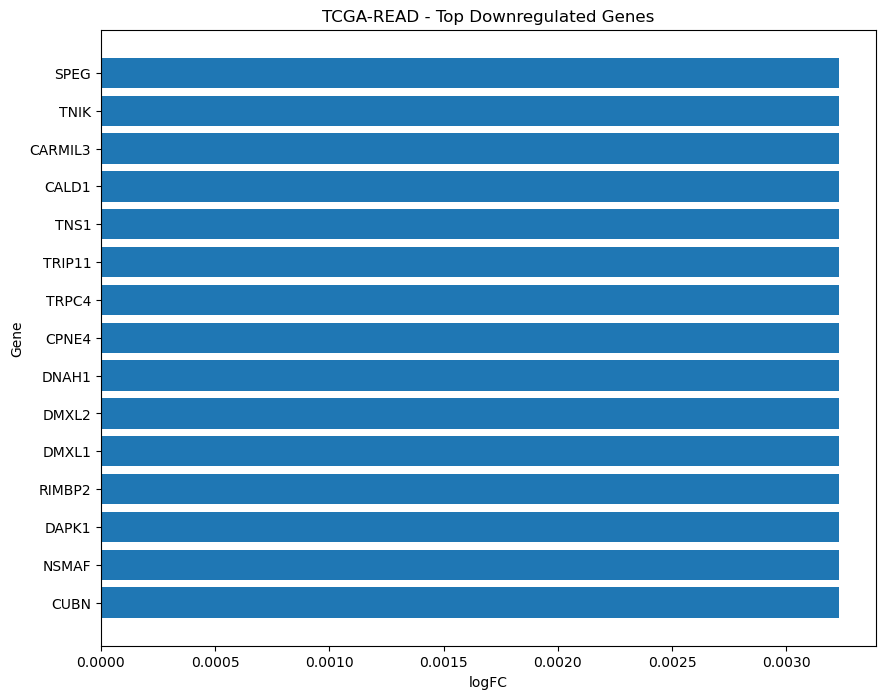


=== TCGA-SARC ===
[cache] file IDs: TCGA-SARC


[cache] mutation matrix: TCGA-SARC
[cache] mutation scores: TCGA-SARC


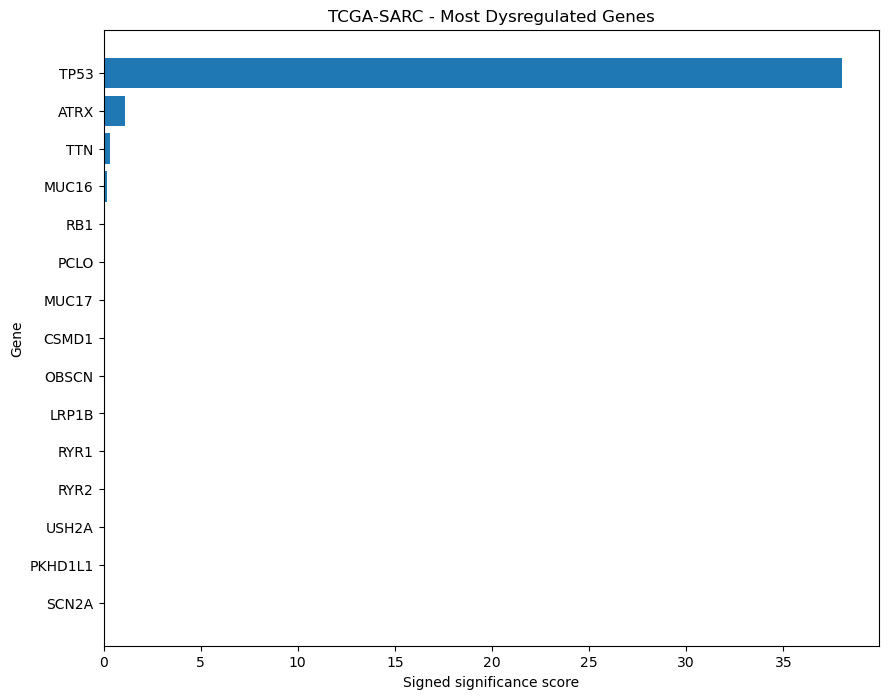

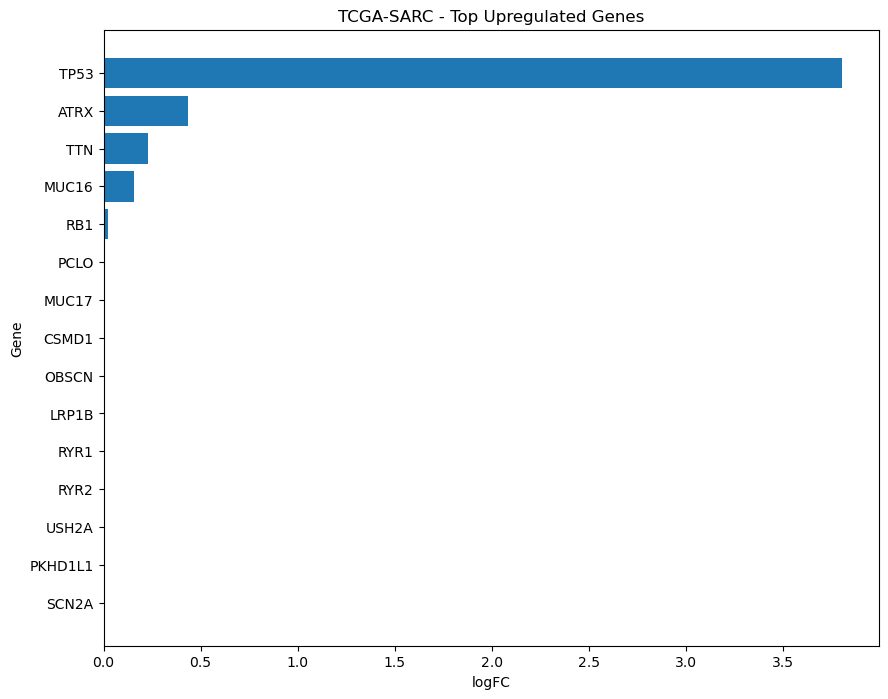

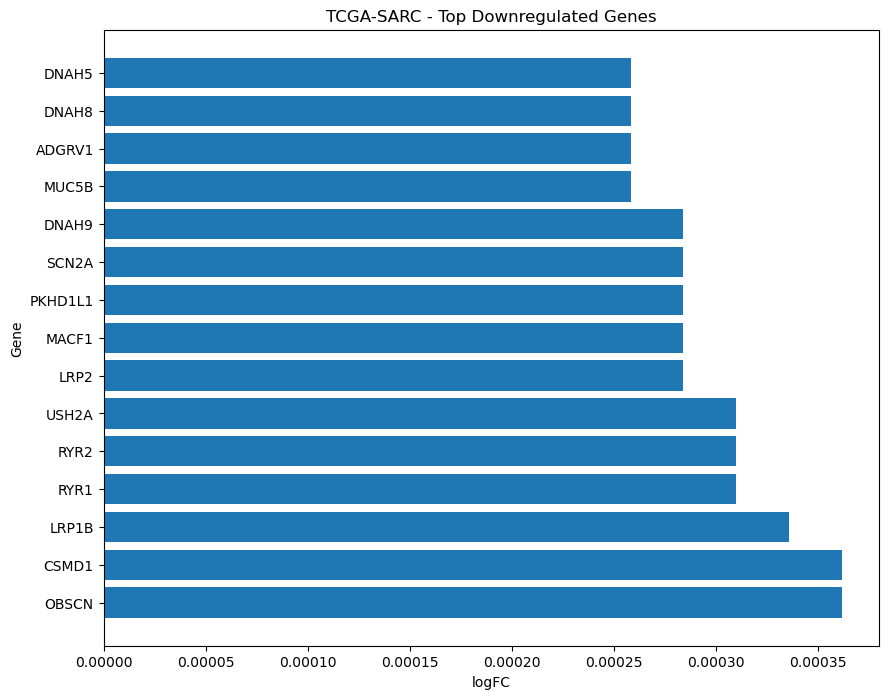


=== TCGA-SKCM ===
[cache] file IDs: TCGA-SKCM


[cache] mutation matrix: TCGA-SKCM
[cache] mutation scores: TCGA-SKCM


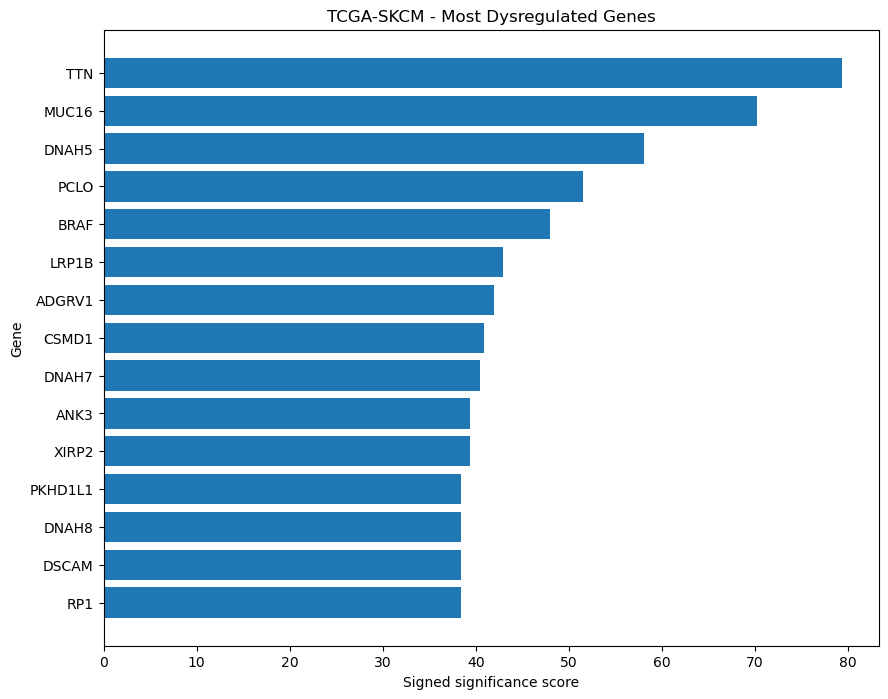

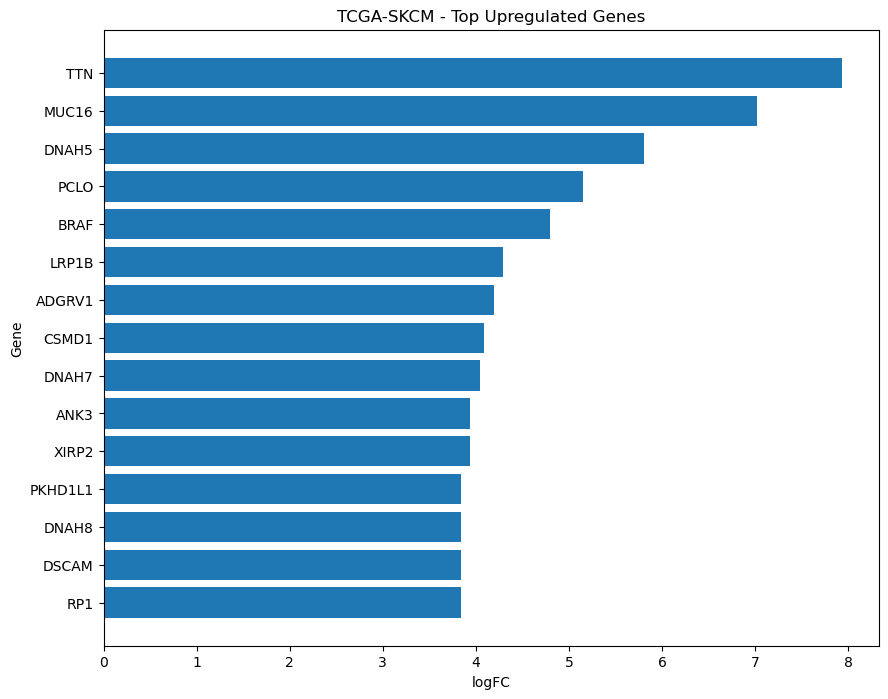

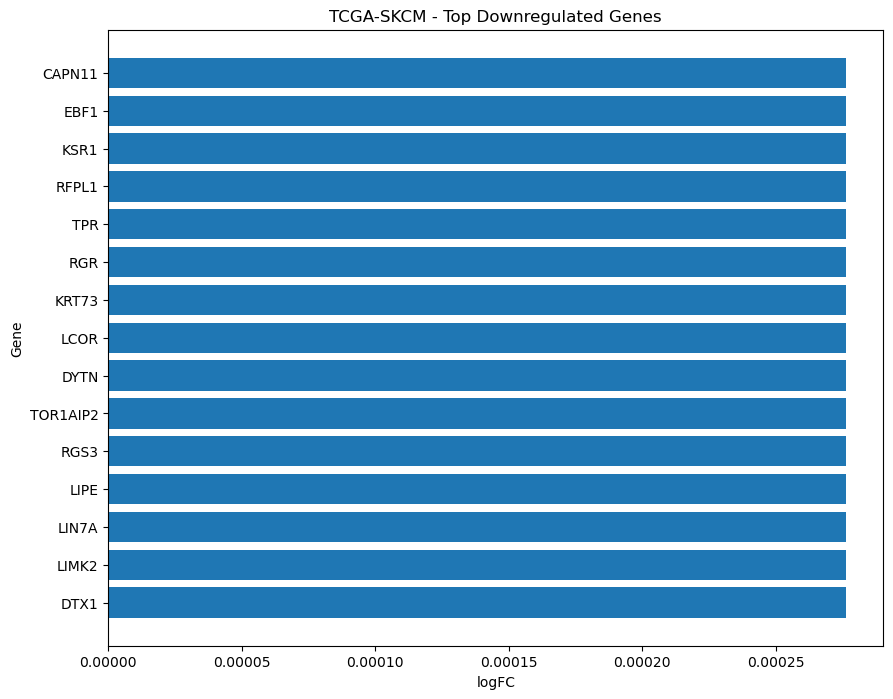


=== TCGA-STAD ===
[cache] file IDs: TCGA-STAD


[cache] mutation matrix: TCGA-STAD
[cache] mutation scores: TCGA-STAD


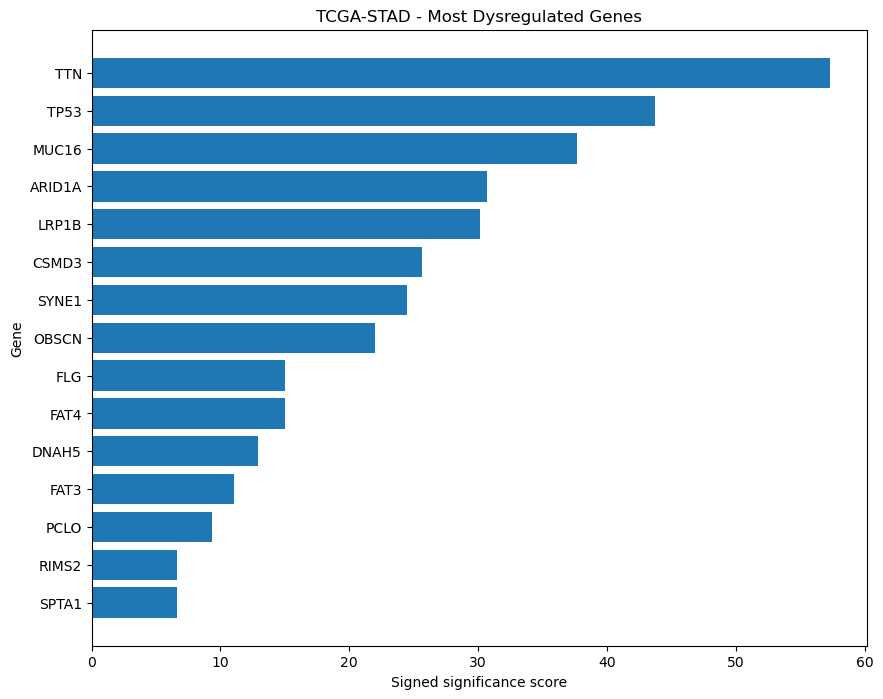

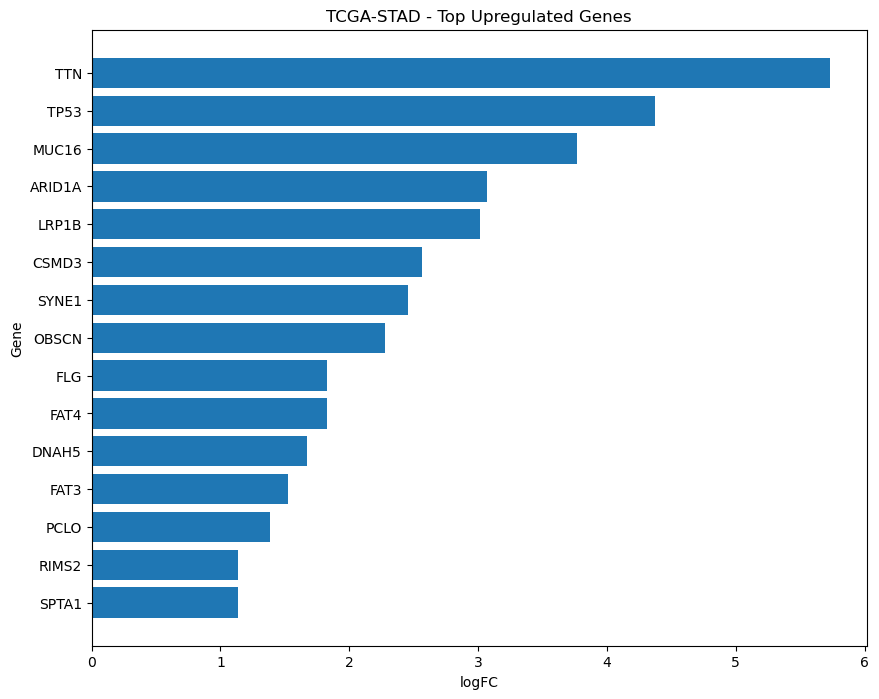

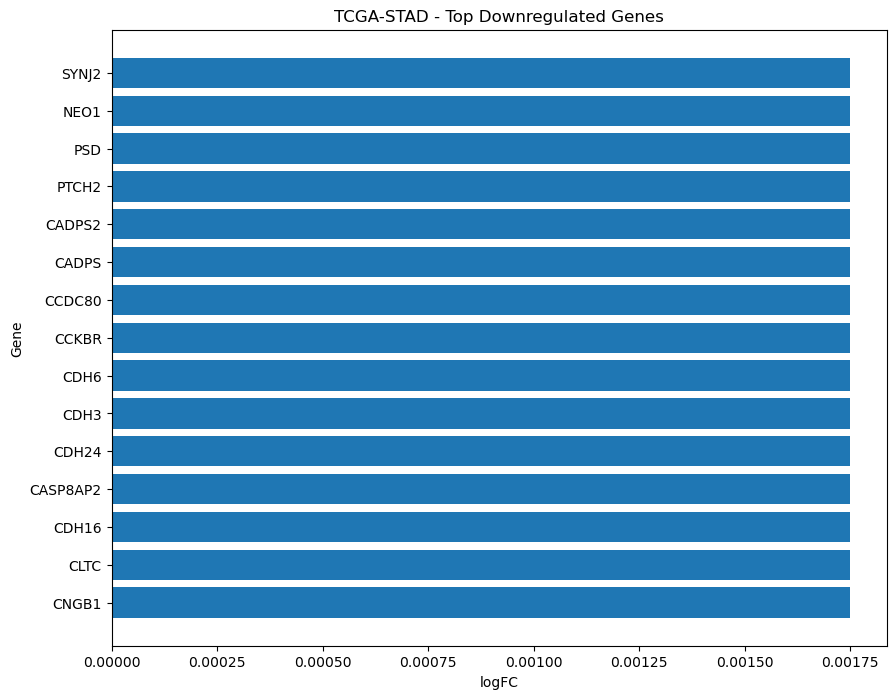


=== TCGA-THCA ===
[cache] file IDs: TCGA-THCA


[cache] mutation matrix: TCGA-THCA
[cache] mutation scores: TCGA-THCA


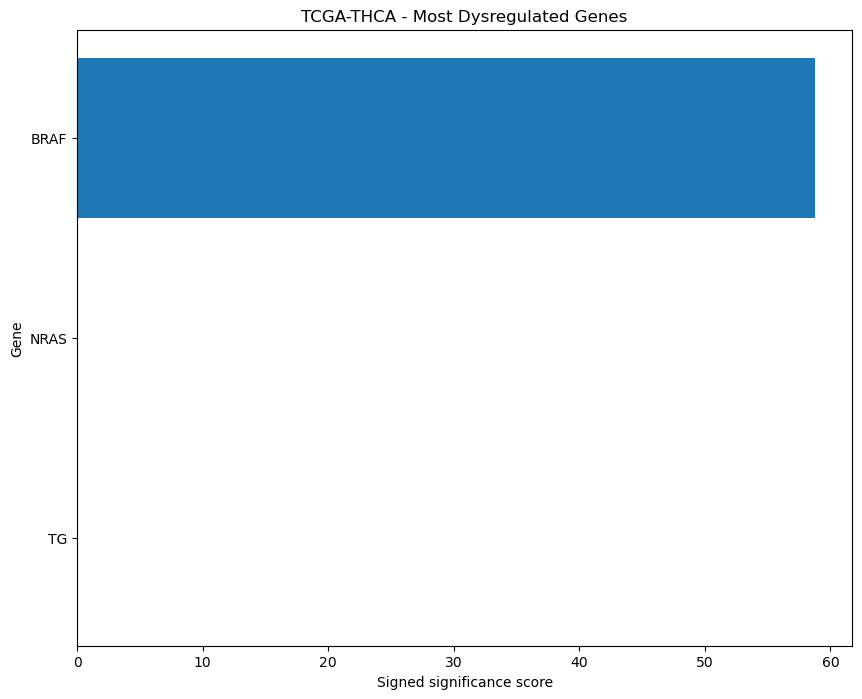

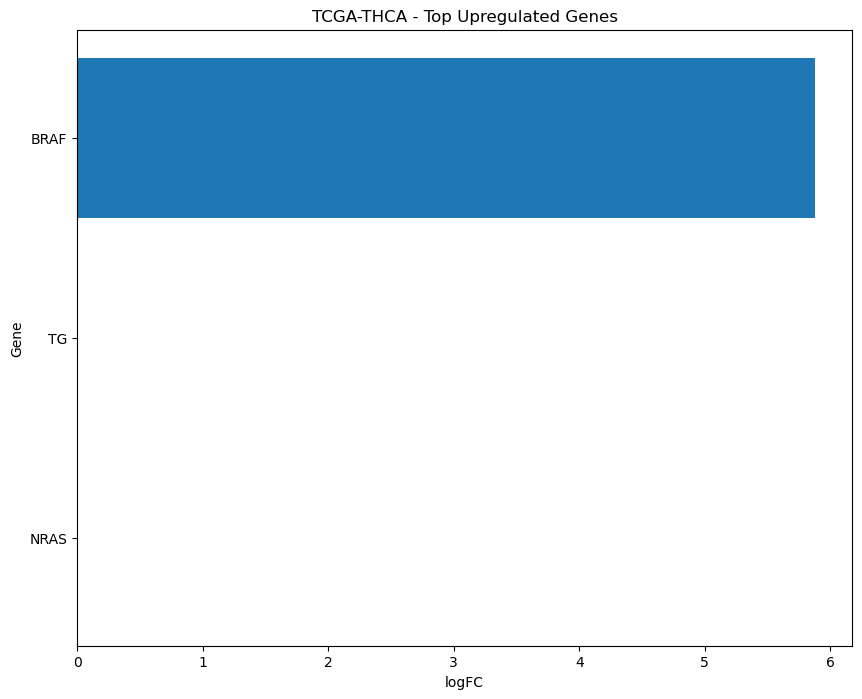

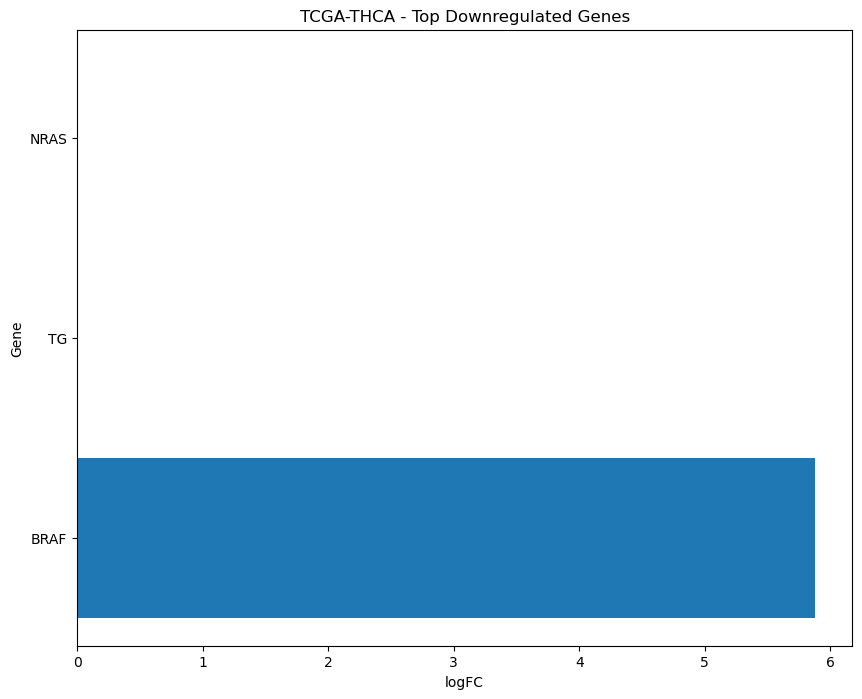


=== TCGA-UCEC ===
[cache] file IDs: TCGA-UCEC


[cache] mutation matrix: TCGA-UCEC
[cache] mutation scores: TCGA-UCEC


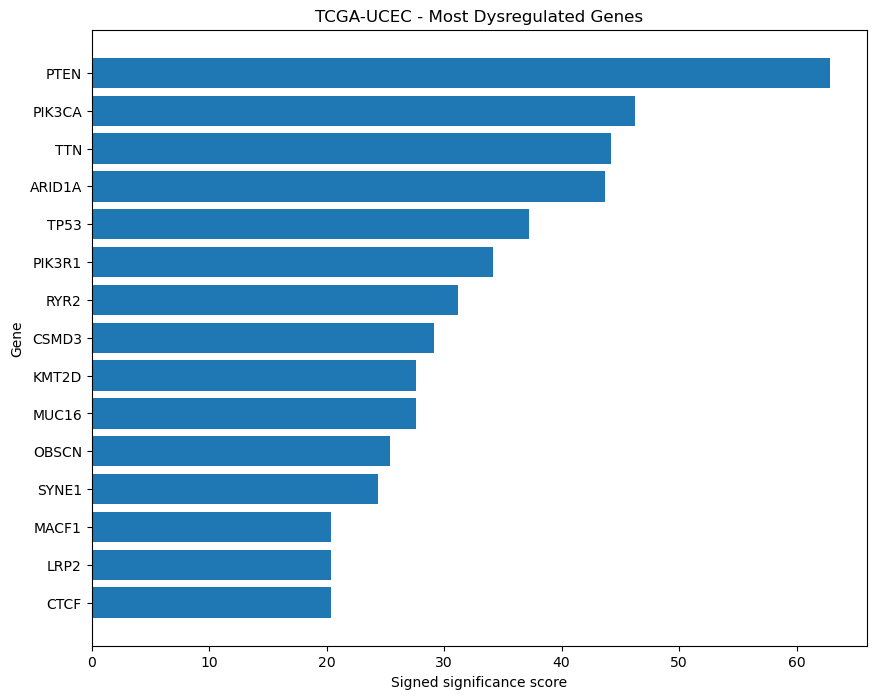

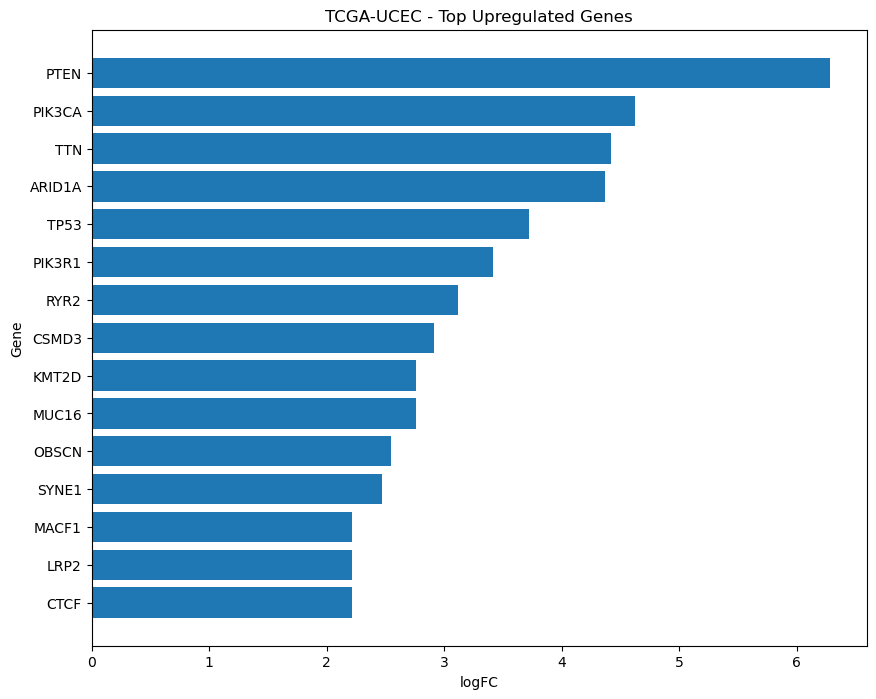

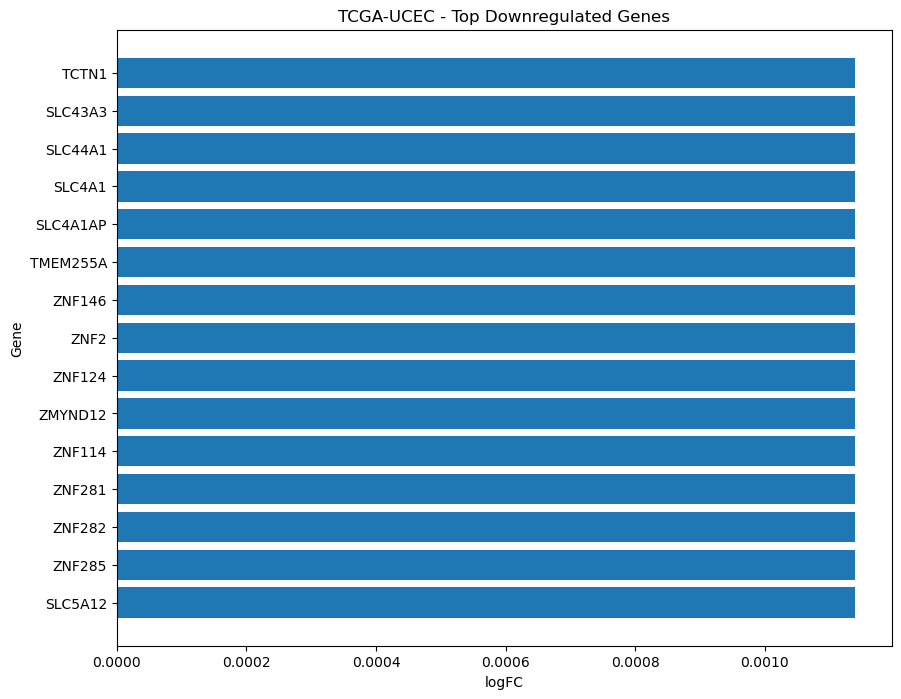

[FINAL] Total genes: 20070
[INFO] Significant genes: 586
✅ Saved mutation outputs (full + significant)


In [4]:
from tqdm.auto import tqdm
import pandas as pd
import numpy as np
from collections import defaultdict
from scipy.stats import binomtest
from pathlib import Path

# ================================
# CONFIG
# ================================
OUT_DIR = Path("../data/gdc_cache")
DATA_DIR = Path("data/tcga_maf")
OUTPUT_DIR = Path("data/tcga_mutation")

OUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ================================
# FDR (Benjamini–Hochberg)
# ================================
def fdr_bh(pvals):
    pvals = np.asarray(pvals)
    n = len(pvals)

    order = np.argsort(pvals)
    ranked = pvals[order]

    fdr = ranked * n / (np.arange(1, n + 1))
    fdr = np.minimum.accumulate(fdr[::-1])[::-1]

    out = np.empty_like(fdr)
    out[order] = fdr

    return np.clip(out, 0, 1)


# ================================
# Load mutation matrix (KEEP ALL GENES)
# ================================
def load_mutation_matrix(project, gene_list=None):
    cancer_dir = DATA_DIR / project

    gene_sample = defaultdict(set)
    all_samples = set()

    for maf_file in cancer_dir.rglob("*.maf*"):
        try:
            df = pd.read_csv(
                maf_file,
                sep="\t",
                comment="#",
                usecols=["Hugo_Symbol", "Tumor_Sample_Barcode"]
            ).dropna()

            for g, s in zip(df["Hugo_Symbol"], df["Tumor_Sample_Barcode"]):
                gene_sample[g].add(s)
                all_samples.add(s)

        except Exception as e:
            print(f"[WARN] {maf_file}: {e}")
            continue

    genes = list(gene_sample.keys())
    samples = list(all_samples)

    # build matrix
    mat = pd.DataFrame(0, index=genes, columns=samples)

    for g, ss in gene_sample.items():
        mat.loc[g, list(ss)] = 1

    # 🔥 IMPORTANT: force full gene space
    if gene_list is not None:
        mat = mat.reindex(gene_list).fillna(0)

    return mat


# ================================
# Mutation scoring (NO FILTERING)
# ================================
def process_mutation(mat):
    print(f"[DEBUG] Mutation matrix: {mat.shape}")

    # mutation frequency
    freq = mat.mean(axis=1)

    # background mutation rate
    background = freq.mean()

    pvals = []

    for g in mat.index:
        k = int(mat.loc[g].sum())
        n = mat.shape[1]

        if n == 0:
            pvals.append(1.0)
            continue

        p = binomtest(k, n, background, alternative="greater").pvalue
        pvals.append(p)

    pval = pd.Series(pvals, index=mat.index).fillna(1.0)
    fdr = pd.Series(fdr_bh(pval.values), index=mat.index)

    # 🔥 stabilized score
    score = (freq + 1e-6) * (-np.log10(fdr + 1e-10))

    df = pd.DataFrame({
        "gene": mat.index,
        "freq": freq,
        "pval": pval,
        "fdr": fdr,
        "score": score
    })

    return df


# ================================
# Cache helpers
# ================================
def load_mutation_matrix_cached(cancer, gene_list):
    cache_file = OUT_DIR / f"{cancer}_mutation_matrix.pkl"

    if cache_file.exists():
        print(f"[cache] mutation matrix: {cancer}")
        return pd.read_pickle(cache_file)

    print(f"[build] mutation matrix: {cancer}")
    mat = load_mutation_matrix(cancer, gene_list)

    mat.to_pickle(cache_file)
    return mat


def process_mutation_cached(mat, cancer):
    cache_file = OUTPUT_DIR / f"{cancer}_mutation_scores.csv"

    if cache_file.exists():
        print(f"[cache] mutation scores: {cancer}")
        return pd.read_csv(cache_file)

    print(f"[compute] mutation scores: {cancer}")
    df = process_mutation(mat)

    df.to_csv(cache_file, index=False)
    return df


# ================================
# MAIN
# ================================
gene_list, gene_map, gene_annot = parse_gtf()

mutation_dict = {}

for cancer in CANCERS:
    print(f"\n=== {cancer} ===")

    file_ids = get_maf_file_ids(cancer)
    download_maf_files(file_ids, cancer)

    mat = load_mutation_matrix_cached(cancer, gene_list)
    df = process_mutation_cached(mat, cancer)

    mutation_dict[cancer] = df

    # plotting
    df_plot = df.set_index("gene")

    plot_top_genes_combined(df_plot.rename(columns={"score": "logFC"}), cancer)
    plot_top_genes_logfc(df_plot.rename(columns={"score": "logFC"}), cancer)


# ================================
# Aggregate (FULL GENE SPACE)
# ================================
MF_all = pd.DataFrame(index=gene_list)
MF_pval_all = pd.DataFrame(index=gene_list)
MF_fdr_all = pd.DataFrame(index=gene_list)

for cancer, df in mutation_dict.items():

    df = df.set_index("gene")

    # 🔥 enforce full gene alignment
    df = df.reindex(gene_list)

    MF_all[cancer] = df["score"]
    MF_pval_all[cancer] = df["pval"]
    MF_fdr_all[cancer] = df["fdr"]


# ================================
# KEEP ALL GENES (NO FILTER)
# ================================
MF_all = MF_all.fillna(0)
MF_pval_all = MF_pval_all.fillna(1.0)
MF_fdr_all = MF_fdr_all.fillna(1.0)

print(f"[FINAL] Total genes: {len(MF_all)}")


# ================================
# OPTIONAL: significant subset
# ================================
sig_mask = (MF_fdr_all < 0.05).any(axis=1)

MF_sig = MF_all.loc[sig_mask]

print(f"[INFO] Significant genes: {sig_mask.sum()}")


# ================================
# Save
# ================================
MF_all.to_csv(OUTPUT_DIR / "mutation_features_full.csv")
MF_pval_all.to_csv(OUTPUT_DIR / "mutation_pvalues_full.csv")
MF_fdr_all.to_csv(OUTPUT_DIR / "mutation_fdr_full.csv")

MF_sig.to_csv(OUTPUT_DIR / "mutation_features_sig.csv")

print("✅ Saved mutation outputs (full + significant)")

In [ ]:
from tqdm.auto import tqdm
import pandas as pd
import numpy as np
from collections import defaultdict

# ================================
# FDR 
# ================================
def fdr_bh(pvals):
    pvals = np.asarray(pvals)
    n = len(pvals)

    order = np.argsort(pvals)
    ranked = pvals[order]

    fdr = ranked * n / (np.arange(1, n + 1))
    fdr = np.minimum.accumulate(fdr[::-1])[::-1]

    out = np.empty_like(fdr)
    out[order] = fdr

    return np.clip(out, 0, 1)


# ================================
# Load mutation data → binary matrix
# ================================
def load_mutation_matrix(project, gene_list=None):
    cancer_dir = DATA_DIR / project

    gene_sample = defaultdict(set)
    all_samples = set()

    for maf_file in cancer_dir.rglob("*.maf*"):
        try:
            df = pd.read_csv(
                maf_file,
                sep="\t",
                comment="#",
                usecols=["Hugo_Symbol", "Tumor_Sample_Barcode"]
            ).dropna()

            for g, s in zip(df["Hugo_Symbol"], df["Tumor_Sample_Barcode"]):
                gene_sample[g].add(s)
                all_samples.add(s)

        except:
            continue

    genes = list(gene_sample.keys())
    samples = list(all_samples)

    mat = pd.DataFrame(0, index=genes, columns=samples)

    for g, ss in gene_sample.items():
        mat.loc[g, list(ss)] = 1

    if gene_list is not None:
        mat = mat.reindex(gene_list).fillna(0)

    return mat


# ================================
# Mutation "differential" scoring
# ================================
def process_mutation(mat, min_samples=10):
    print(f"[DEBUG] Mutation matrix: {mat.shape}")

    # remove rare genes
    gene_counts = mat.sum(axis=1)
    mat = mat[gene_counts >= min_samples]

    print(f"[DEBUG] After filtering: {mat.shape}")

    # mutation frequency
    freq = mat.mean(axis=1)

    # binomial test vs background
    background = freq.mean()

    pvals = []
    for g in mat.index:
        k = int(mat.loc[g].sum())
        n = mat.shape[1]

        # simple enrichment test
        p = binomtest(k, n, background, alternative="greater").pvalue
        pvals.append(p)

        pval = pd.Series(pvals, index=mat.index)
        fdr = pd.Series(fdr_bh(pval.values), index=mat.index)

        # ✅ MODIFY HERE
        score = (freq + 1e-6) * (-np.log10(fdr + 1e-10))

        df = pd.DataFrame({
            "gene": mat.index,
            "freq": freq,
            "pval": pval,
            "fdr": fdr,
            "score": score
        }).sort_values("fdr")

    return df


def load_mutation_matrix_cached(cancer, gene_list):
    cache_file = OUT_DIR / f"{cancer}_mutation_matrix.pkl"

    if cache_file.exists():
        print(f"[cache] mutation matrix: {cancer}")
        return pd.read_pickle(cache_file)

    print(f"[build] mutation matrix: {cancer}")
    mat = load_mutation_matrix(cancer, gene_list)

    mat.to_pickle(cache_file)
    return mat



def process_mutation_cached(mat, cancer):
    cache_file = OUTPUT_DIR / f"{cancer}_mutation_scores.csv"

    if cache_file.exists():
        print(f"[cache] mutation scores: {cancer}")
        return pd.read_csv(cache_file)

    print(f"[compute] mutation scores: {cancer}")
    df = process_mutation(mat)

    df.to_csv(cache_file, index=False)
    return df



# ================================
# MAIN
# ================================
gene_list, gene_map, gene_annot = parse_gtf()

mutation_dict = {}

for cancer in CANCERS:
    print(f"\n=== {cancer} ===")

    file_ids = get_maf_file_ids(cancer)
    download_maf_files(file_ids, cancer)

    # mat = load_mutation_matrix(cancer, gene_list)

    # df = process_mutation(mat)

    mat = load_mutation_matrix_cached(cancer, gene_list)
    df = process_mutation_cached(mat, cancer)

    mutation_dict[cancer] = df

    # plotting
    df_plot = df.set_index("gene")

    plot_top_genes_combined(df_plot.rename(columns={"score": "logFC"}), cancer)
    plot_top_genes_logfc(df_plot.rename(columns={"score": "logFC"}), cancer)


# ================================
# Aggregate
# ================================
MF_all = pd.DataFrame(index=gene_list)
MF_pval_all = pd.DataFrame(index=gene_list)
MF_fdr_all = pd.DataFrame(index=gene_list)

for cancer, df in mutation_dict.items():
    df = df.set_index("gene")

    MF_all[cancer] = df["score"]
    MF_pval_all[cancer] = df["pval"]
    MF_fdr_all[cancer] = df["fdr"]


# # ================================
# # Filtering
# # ================================
# mask = (MF_fdr_all < 0.05).any(axis=1)

# MF_all = MF_all.loc[mask]
# MF_pval_all = MF_pval_all.loc[mask]
# MF_fdr_all = MF_fdr_all.loc[mask]

# print(f"[FINAL] Kept {mask.sum()} genes")


# # ================================
# # Save
# # ================================
# MF_all.to_csv(OUTPUT_DIR / "mutation_features.csv")
# MF_pval_all.to_csv(OUTPUT_DIR / "mutation_pvalues.csv")
# MF_fdr_all.to_csv(OUTPUT_DIR / "mutation_fdr.csv")

# print("✅ Saved mutation outputs")

from tqdm.auto import tqdm
import pandas as pd
import numpy as np
from collections import defaultdict
from scipy.stats import binomtest
from pathlib import Path

# ================================
# CONFIG
# ================================
OUT_DIR = Path("../data/gdc_cache")
DATA_DIR = Path("data/tcga_maf")
OUTPUT_DIR = Path("data/tcga_mutation")

OUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ================================
# FDR (Benjamini–Hochberg)
# ================================
def fdr_bh(pvals):
    pvals = np.asarray(pvals)
    n = len(pvals)

    order = np.argsort(pvals)
    ranked = pvals[order]

    fdr = ranked * n / (np.arange(1, n + 1))
    fdr = np.minimum.accumulate(fdr[::-1])[::-1]

    out = np.empty_like(fdr)
    out[order] = fdr

    return np.clip(out, 0, 1)


# ================================
# Load mutation matrix (KEEP ALL GENES)
# ================================
def load_mutation_matrix(project, gene_list=None):
    cancer_dir = DATA_DIR / project

    gene_sample = defaultdict(set)
    all_samples = set()

    for maf_file in cancer_dir.rglob("*.maf*"):
        try:
            df = pd.read_csv(
                maf_file,
                sep="\t",
                comment="#",
                usecols=["Hugo_Symbol", "Tumor_Sample_Barcode"]
            ).dropna()

            for g, s in zip(df["Hugo_Symbol"], df["Tumor_Sample_Barcode"]):
                gene_sample[g].add(s)
                all_samples.add(s)

        except Exception as e:
            print(f"[WARN] {maf_file}: {e}")
            continue

    genes = list(gene_sample.keys())
    samples = list(all_samples)

    # build matrix
    mat = pd.DataFrame(0, index=genes, columns=samples)

    for g, ss in gene_sample.items():
        mat.loc[g, list(ss)] = 1

    # 🔥 IMPORTANT: force full gene space
    if gene_list is not None:
        mat = mat.reindex(gene_list).fillna(0)

    return mat


# ================================
# Mutation scoring (NO FILTERING)
# ================================
def process_mutation(mat):
    print(f"[DEBUG] Mutation matrix: {mat.shape}")

    # mutation frequency
    freq = mat.mean(axis=1)

    # background mutation rate
    background = freq.mean()

    pvals = []

    for g in mat.index:
        k = int(mat.loc[g].sum())
        n = mat.shape[1]

        if n == 0:
            pvals.append(1.0)
            continue

        p = binomtest(k, n, background, alternative="greater").pvalue
        pvals.append(p)

    pval = pd.Series(pvals, index=mat.index).fillna(1.0)
    fdr = pd.Series(fdr_bh(pval.values), index=mat.index)

    # 🔥 stabilized score
    score = (freq + 1e-6) * (-np.log10(fdr + 1e-10))

    df = pd.DataFrame({
        "gene": mat.index,
        "freq": freq,
        "pval": pval,
        "fdr": fdr,
        "score": score
    })

    return df


# ================================
# Cache helpers
# ================================
def load_mutation_matrix_cached(cancer, gene_list):
    cache_file = OUT_DIR / f"{cancer}_mutation_matrix.pkl"

    if cache_file.exists():
        print(f"[cache] mutation matrix: {cancer}")
        return pd.read_pickle(cache_file)

    print(f"[build] mutation matrix: {cancer}")
    mat = load_mutation_matrix(cancer, gene_list)

    mat.to_pickle(cache_file)
    return mat


def process_mutation_cached(mat, cancer):
    cache_file = OUTPUT_DIR / f"{cancer}_mutation_scores.csv"

    if cache_file.exists():
        print(f"[cache] mutation scores: {cancer}")
        return pd.read_csv(cache_file)

    print(f"[compute] mutation scores: {cancer}")
    df = process_mutation(mat)

    df.to_csv(cache_file, index=False)
    return df

from scipy.stats import poisson

def process_mutation_advanced(mat, gene_annot):

    print(f"[DEBUG] Mutation matrix: {mat.shape}")

    # -------------------------------
    # Observed mutations
    # -------------------------------
    gene_counts = mat.sum(axis=1)

    # -------------------------------
    # Sample mutation rates
    # -------------------------------
    sample_mut_counts = mat.sum(axis=0)
    total_genes = mat.shape[0]

    mu = sample_mut_counts / total_genes

    # -------------------------------
    # Gene length normalization
    # -------------------------------
    gene_lengths = {
        g: (end - start + 1)
        for g, (_, start, end) in gene_annot.items()
    }

    gene_len = pd.Series(gene_lengths).reindex(mat.index)
    gene_len = gene_len.fillna(gene_len.median())

    gene_len_norm = gene_len / gene_len.mean()

    # -------------------------------
    # Expected mutations
    # -------------------------------
    expected = gene_len_norm * mu.sum()

    # -------------------------------
    # Poisson test
    # -------------------------------
    observed = gene_counts

    pvals = poisson.sf(observed - 1, expected)

    pval = pd.Series(pvals, index=mat.index)
    fdr = pd.Series(fdr_bh(pval.values), index=mat.index)

    # -------------------------------
    # Driver score
    # -------------------------------
    enrichment = observed / (expected + 1e-6)

    score = enrichment * (-np.log10(fdr + 1e-10))

    df = pd.DataFrame({
        "gene": mat.index,
        "observed": observed,
        "expected": expected,
        "enrichment": enrichment,
        "pval": pval,
        "fdr": fdr,
        "score": score
    }).sort_values("fdr")

    return df

# ================================
# MAIN
# ================================
gene_list, gene_map, gene_annot = parse_gtf()

mutation_dict = {}

for cancer in CANCERS:
    print(f"\n=== {cancer} ===")

    file_ids = get_maf_file_ids(cancer)
    download_maf_files(file_ids, cancer)

    mat = load_mutation_matrix_cached(cancer, gene_list)
    # df = process_mutation_cached(mat, cancer)
    df = process_mutation_advanced(mat, gene_annot)

    mutation_dict[cancer] = df

    # plotting
    df_plot = df.set_index("gene")

    plot_top_genes_combined(df_plot.rename(columns={"score": "logFC"}), cancer)
    plot_top_genes_logfc(df_plot.rename(columns={"score": "logFC"}), cancer)


# ================================
# Aggregate (FULL GENE SPACE)
# ================================
MF_all = pd.DataFrame(index=gene_list)
MF_pval_all = pd.DataFrame(index=gene_list)
MF_fdr_all = pd.DataFrame(index=gene_list)

for cancer, df in mutation_dict.items():

    df = df.set_index("gene")

    # 🔥 enforce full gene alignment
    df = df.reindex(gene_list)

    MF_all[cancer] = df["score"]
    MF_pval_all[cancer] = df["pval"]
    MF_fdr_all[cancer] = df["fdr"]


# ================================
# KEEP ALL GENES (NO FILTER)
# ================================
MF_all = MF_all.fillna(0)
MF_pval_all = MF_pval_all.fillna(1.0)
MF_fdr_all = MF_fdr_all.fillna(1.0)

print(f"[FINAL] Total genes: {len(MF_all)}")


# ================================
# OPTIONAL: significant subset
# ================================
sig_mask = (MF_fdr_all < 0.05).any(axis=1)

MF_sig = MF_all.loc[sig_mask]

print(f"[INFO] Significant genes: {sig_mask.sum()}")


# ================================
# Save
# ================================
MF_all.to_csv(OUTPUT_DIR / "mutation_features_full.csv")
MF_pval_all.to_csv(OUTPUT_DIR / "mutation_pvalues_full.csv")
MF_fdr_all.to_csv(OUTPUT_DIR / "mutation_fdr_full.csv")

MF_sig.to_csv(OUTPUT_DIR / "mutation_features_sig.csv")

print("✅ Saved mutation outputs (full + significant)")

[cache] GTF


Parsing GTF: 0it [00:00, ?it/s]

Parsing GTF: 4354237it [00:04, 964768.60it/s]